# DIABETES PREDICTION
This workbook demonstrates prediction of diabetes of patients with ML models. 

In [546]:
import opendatasets as od
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif,RFECV,mutual_info_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import make_column_selector,make_column_transformer,ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import tensorflow as tf
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,roc_auc_score,roc_curve
from category_encoders import MEstimateEncoder
from sklearn.decomposition import PCA
from lightgbm import LGBMClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import xgboost as xgb
from sklearn.utils import shuffle
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor,AdaBoostClassifier,StackingClassifier,HistGradientBoostingClassifier
import re
from scipy.stats import randint,uniform,rankdata
from sklearn.model_selection import learning_curve,LearningCurveDisplay
import optuna
import lightgbm as lgb
from tqdm import tqdm
from pytabkit import TabM_D_Classifier
from catboost import CatBoostClassifier
import optunahub
from optuna.distributions import IntDistribution 

In [197]:
# od.download_kaggle_dataset("https://www.kaggle.com/competitions/playground-series-s5e12",data_dir="./datasets")

In [198]:
diabetes_train_df = pd.read_csv("./datasets/diabetes/train.csv")
diabetes_test_df = pd.read_csv("./datasets/diabetes/test.csv")

In [199]:
diabetes_train_df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [200]:
X_train = diabetes_train_df
X_test = diabetes_test_df

In [201]:
X_train.isna().any()

id                                    False
age                                   False
alcohol_consumption_per_week          False
physical_activity_minutes_per_week    False
diet_score                            False
sleep_hours_per_day                   False
screen_time_hours_per_day             False
bmi                                   False
waist_to_hip_ratio                    False
systolic_bp                           False
diastolic_bp                          False
heart_rate                            False
cholesterol_total                     False
hdl_cholesterol                       False
ldl_cholesterol                       False
triglycerides                         False
gender                                False
ethnicity                             False
education_level                       False
income_level                          False
smoking_status                        False
employment_status                     False
family_history_diabetes         

In [202]:
X_test.isna().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [203]:
ytrain = X_train.pop('diagnosed_diabetes')

#### VISUALIZE DATA

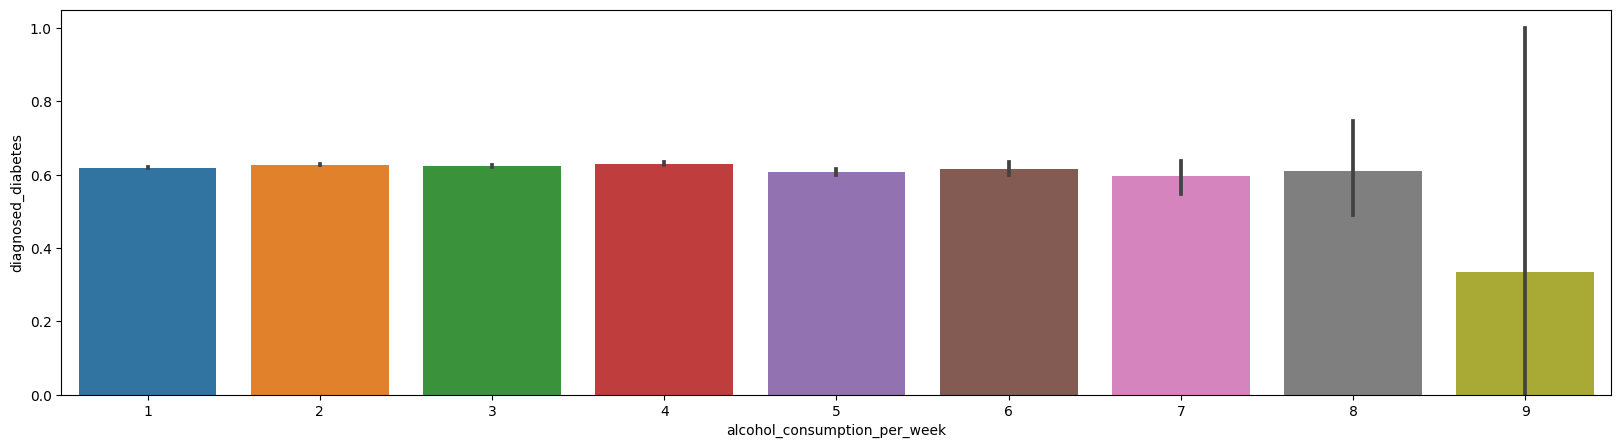

In [204]:
plt.figure(figsize=(20,5))
sns.barplot(data=X_train,x='alcohol_consumption_per_week',y=ytrain)
plt.show()

In [205]:
X_train = X_train.join(ytrain)

In [206]:
X_train.groupby(['alcohol_consumption_per_week'])['diagnosed_diabetes'].agg('mean')

alcohol_consumption_per_week
1    0.618856
2    0.626813
3    0.624490
4    0.629434
5    0.606440
6    0.614370
7    0.595078
8    0.610169
9    0.333333
Name: diagnosed_diabetes, dtype: float64

In [207]:
X_train.groupby(['physical_activity_minutes_per_week'])['diagnosed_diabetes'].agg(['mean'])

,mean
physical_activity_minutes_per_week,
1,1.000000
2,1.000000
3,0.500000
4,0.467742
5,0.638298
...,...
647,1.000000
651,1.000000
664,0.000000


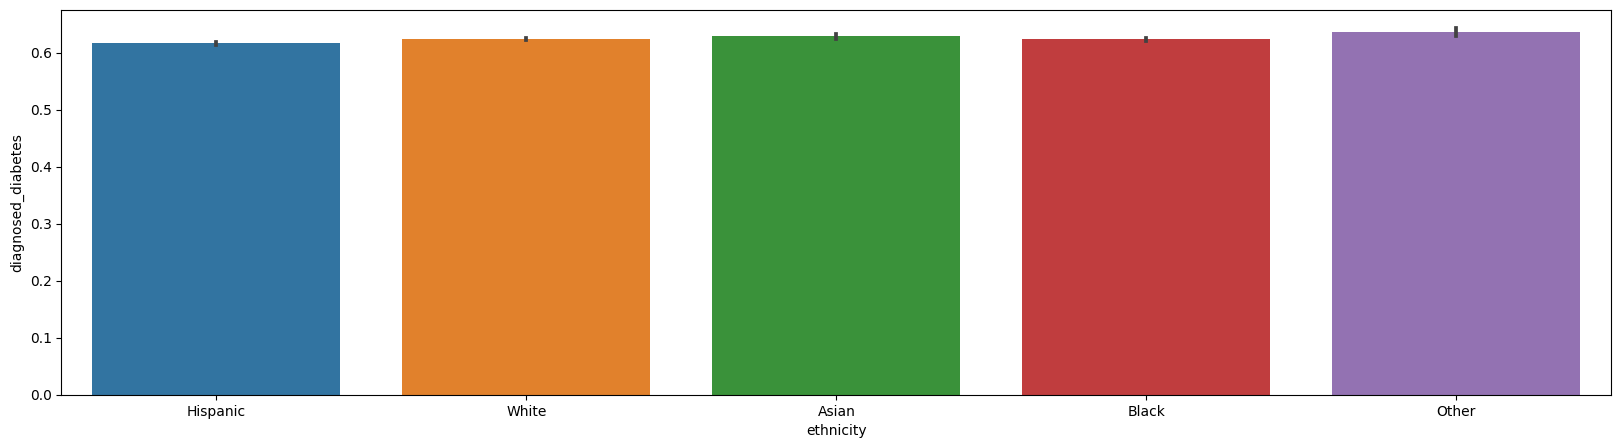

In [208]:
plt.figure(figsize=(20,5))
sns.barplot(data=X_train,x='ethnicity',y=ytrain)
plt.show()

In [209]:
ethnicity_alcoholconsumption_df = X_train.groupby(['ethnicity','alcohol_consumption_per_week'])['diagnosed_diabetes'].agg(['mean'])

In [210]:
ethnicity_alcoholconsumption_df.head(10)

mean
ethnicity alcohol_consumption_per_week          
Asian     1                             0.627190
          2                             0.631072
          3                             0.624873
          4                             0.630807
          5                             0.632956
          6                             0.619910
          7                             0.615385
          8                             1.000000
Black     1                             0.617921
          2                             0.628766

In [211]:
list(ethnicity_alcoholconsumption_df.loc['Asian'].index)

[1, 2, 3, 4, 5, 6, 7, 8]

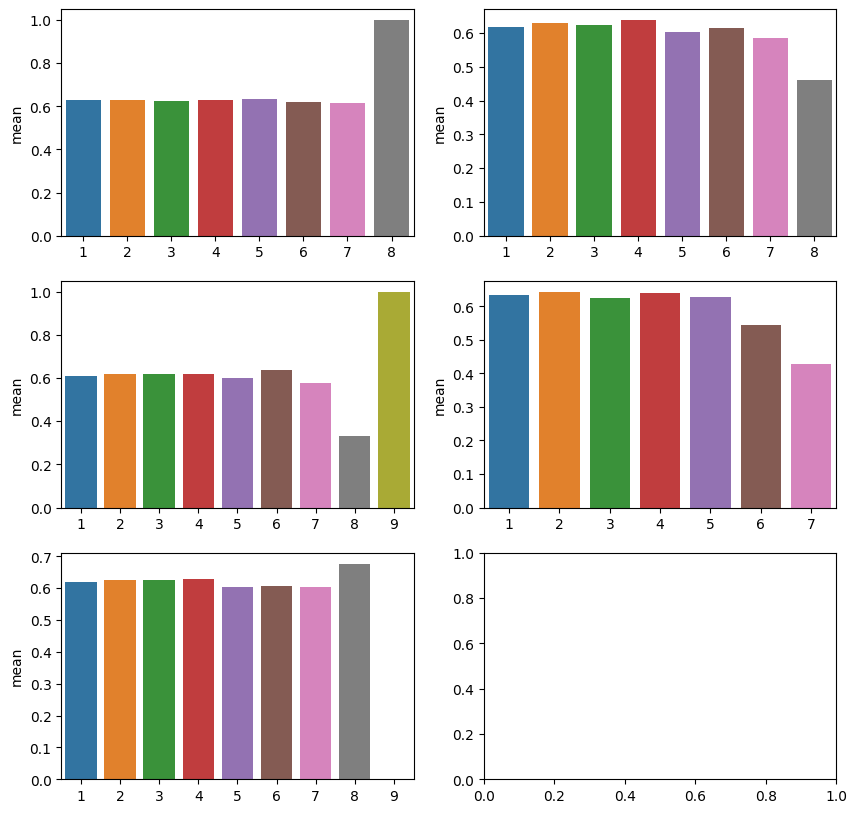

In [212]:
fig,axes = plt.subplots(nrows=3,ncols=2)

fig.set_figheight(10)
fig.set_figwidth(10)

sns.barplot(x=list(ethnicity_alcoholconsumption_df.loc['Asian'].index),y=ethnicity_alcoholconsumption_df.loc['Asian','mean'],ax=axes[0,0])
sns.barplot(x=list(ethnicity_alcoholconsumption_df.loc['Black'].index),y=ethnicity_alcoholconsumption_df.loc['Black','mean'],ax=axes[0,1])
sns.barplot(x=list(ethnicity_alcoholconsumption_df.loc['Hispanic'].index),y=ethnicity_alcoholconsumption_df.loc['Hispanic','mean'],ax=axes[1,0])
sns.barplot(x=list(ethnicity_alcoholconsumption_df.loc['Other'].index),y=ethnicity_alcoholconsumption_df.loc['Other','mean'],ax=axes[1,1])
sns.barplot(x=list(ethnicity_alcoholconsumption_df.loc['White'].index),y=ethnicity_alcoholconsumption_df.loc['White','mean'],ax=axes[2,0])

plt.show()

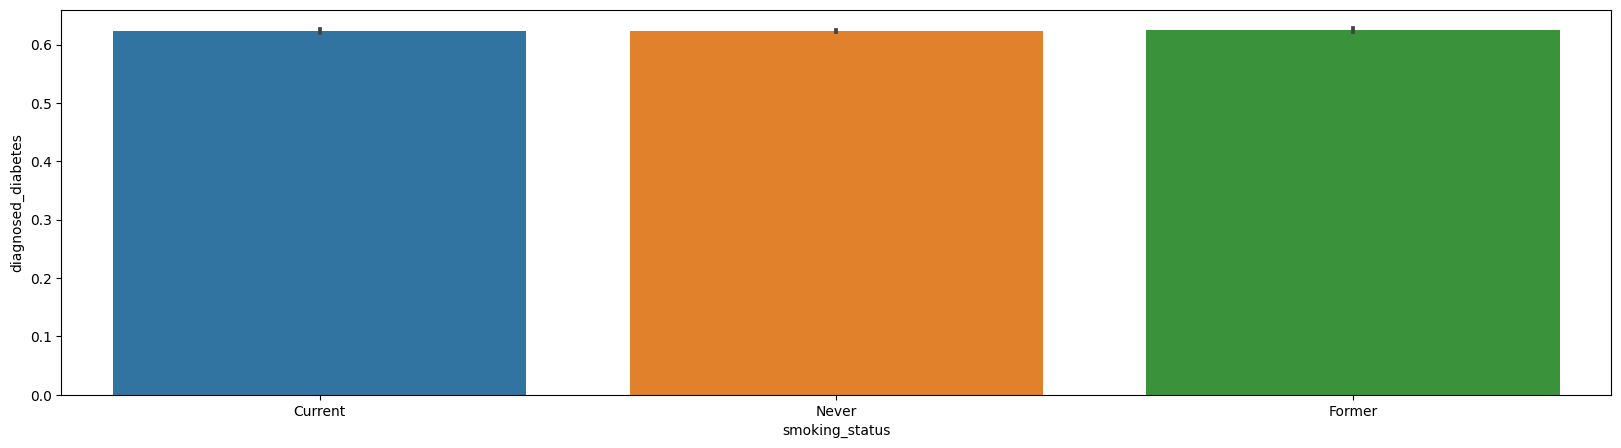

In [213]:
plt.figure(figsize=(20,5))
sns.barplot(data=X_train,x='smoking_status',y=ytrain)
plt.show()

In [214]:
ethnicity_smoke_alcohol_df = X_train.groupby(['ethnicity','smoking_status','alcohol_consumption_per_week'])['diagnosed_diabetes'].agg(['mean'])

In [215]:
ethnicity_smoke_alcohol_df.head(10)

mean
ethnicity smoking_status alcohol_consumption_per_week          
Asian     Current        1                             0.630035
                         2                             0.631497
                         3                             0.625148
                         4                             0.643377
                         5                             0.652439
                         6                             0.625000
                         7                             0.500000
                         8                             1.000000
          Former         1                             0.637671
                         2                             0.632640

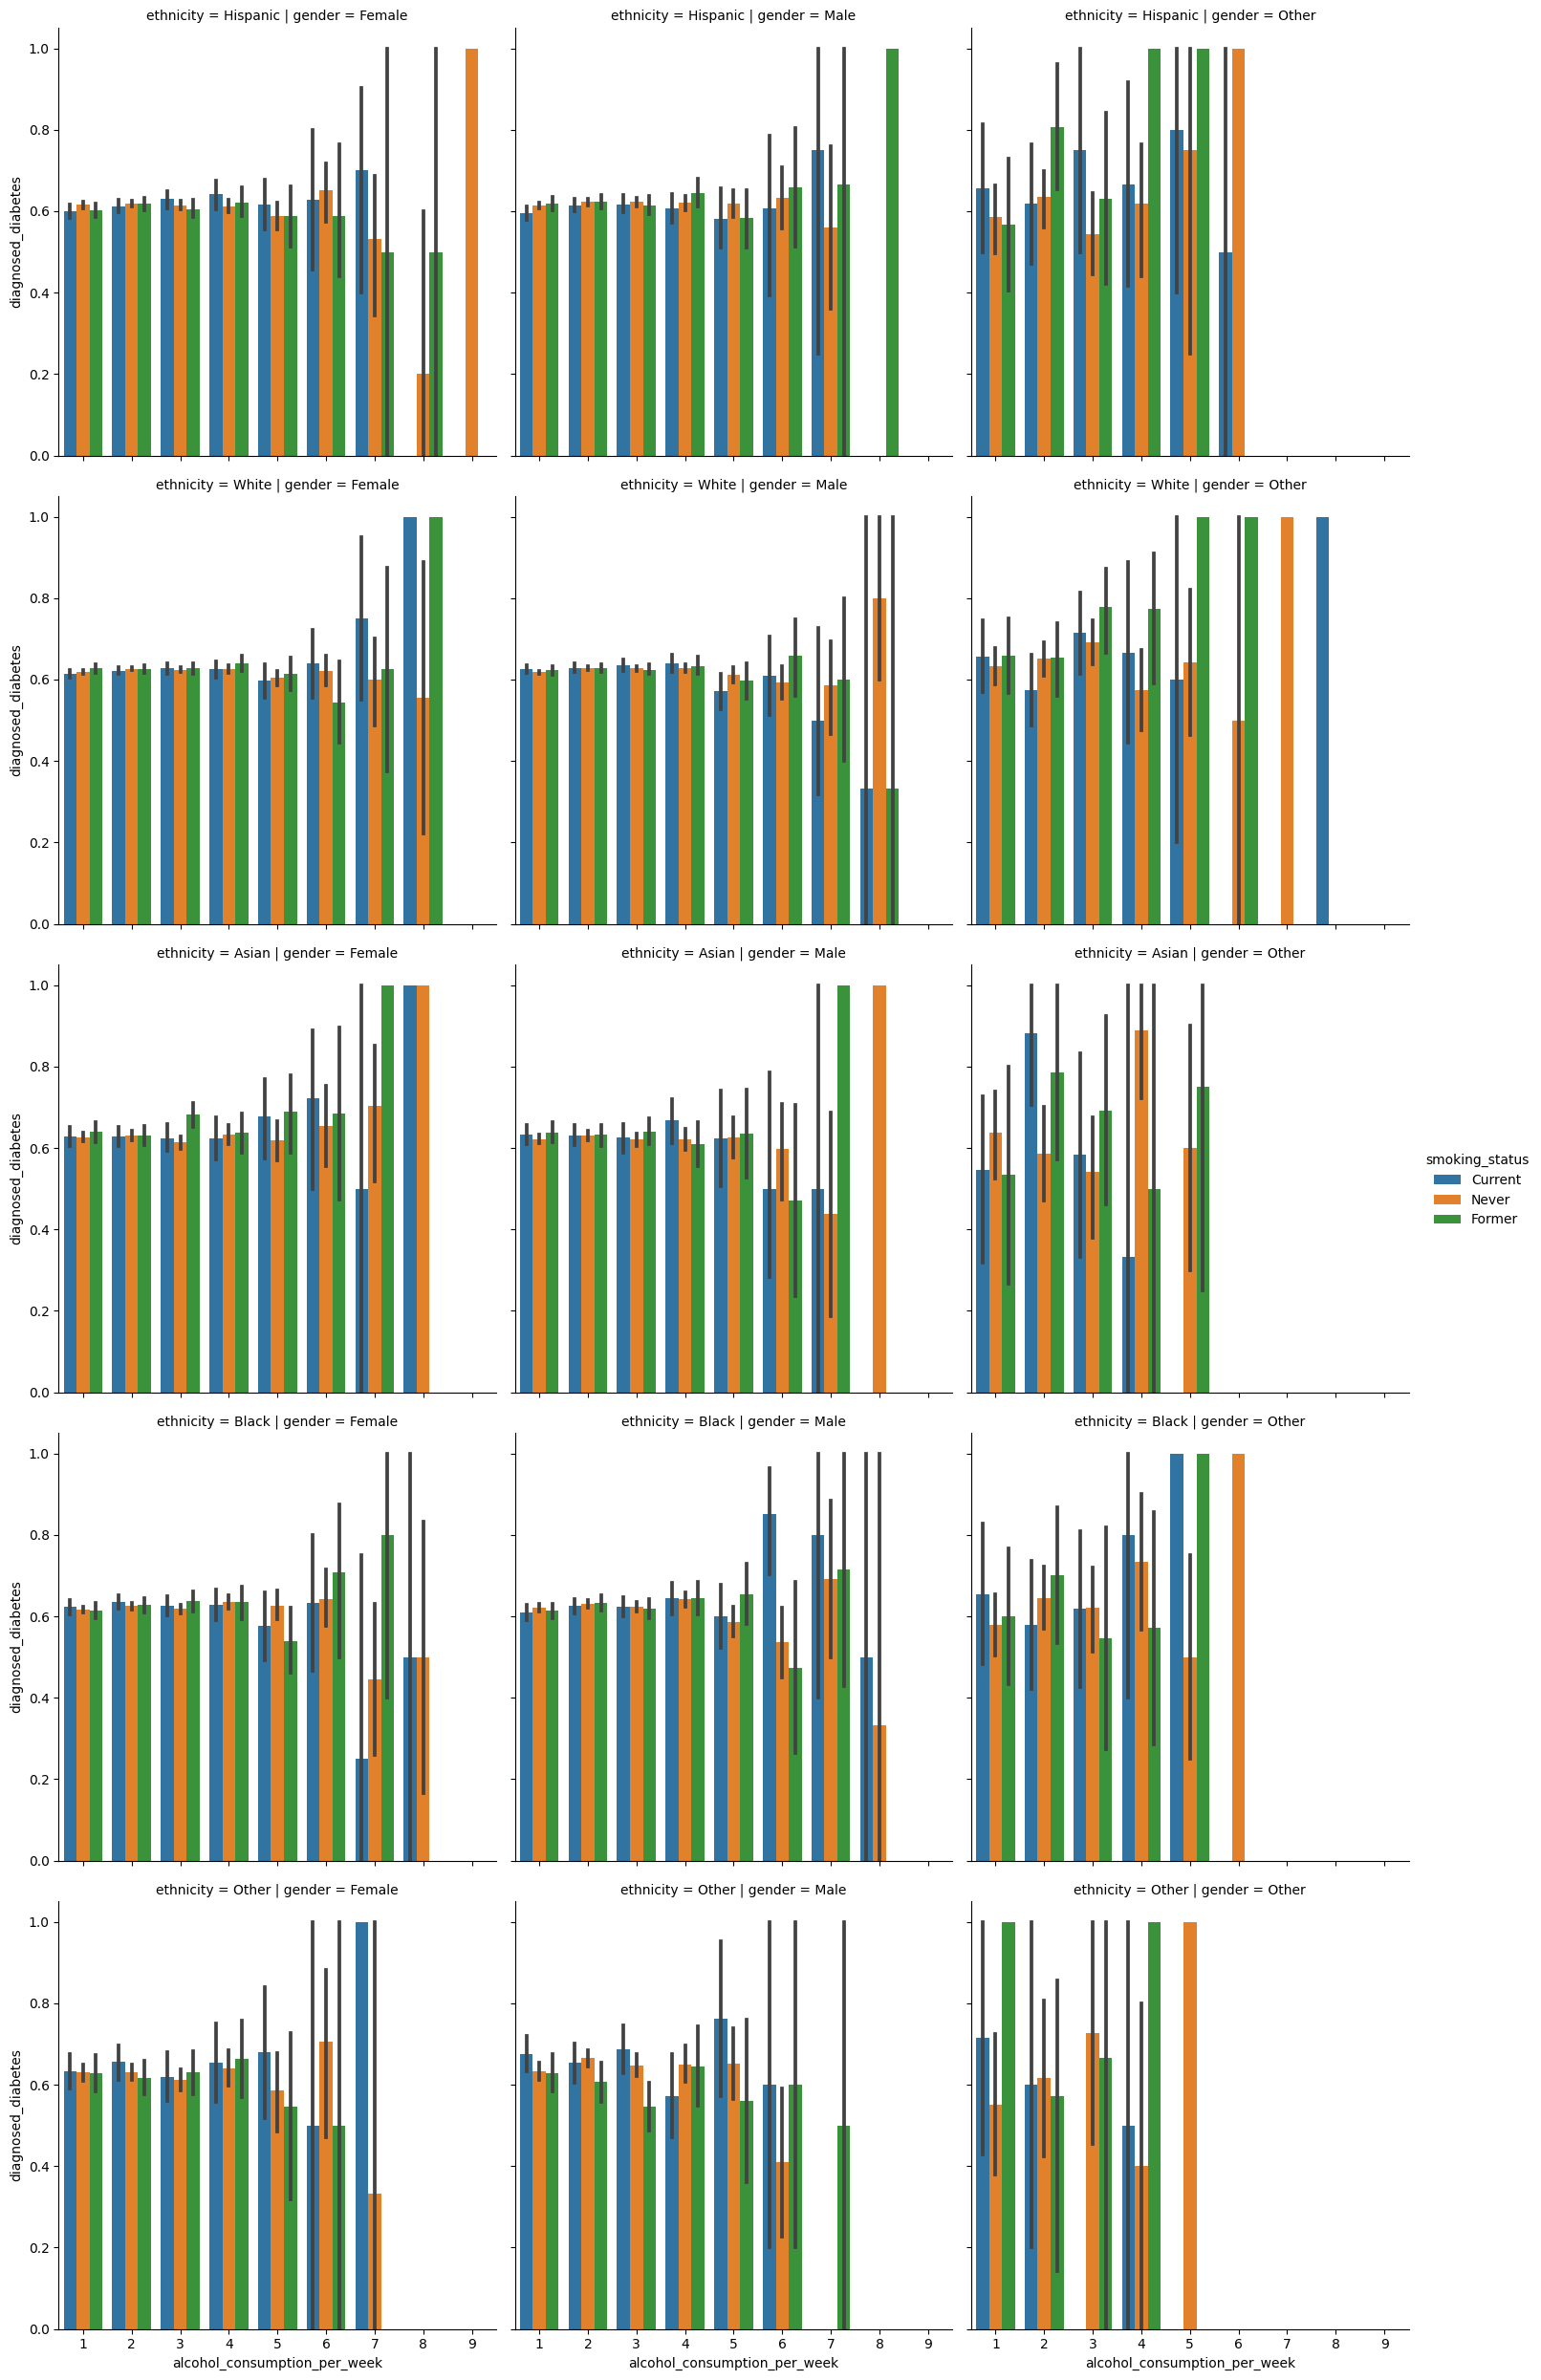

In [216]:
sns.catplot(data=X_train,x='alcohol_consumption_per_week',y='diagnosed_diabetes',kind='bar',row='ethnicity',col='gender',hue='smoking_status')
plt.show()

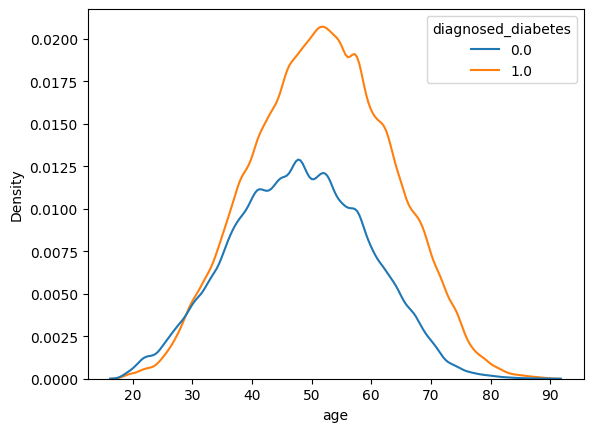

In [217]:
sns.kdeplot(data=X_train,x='age',hue='diagnosed_diabetes')
plt.show()

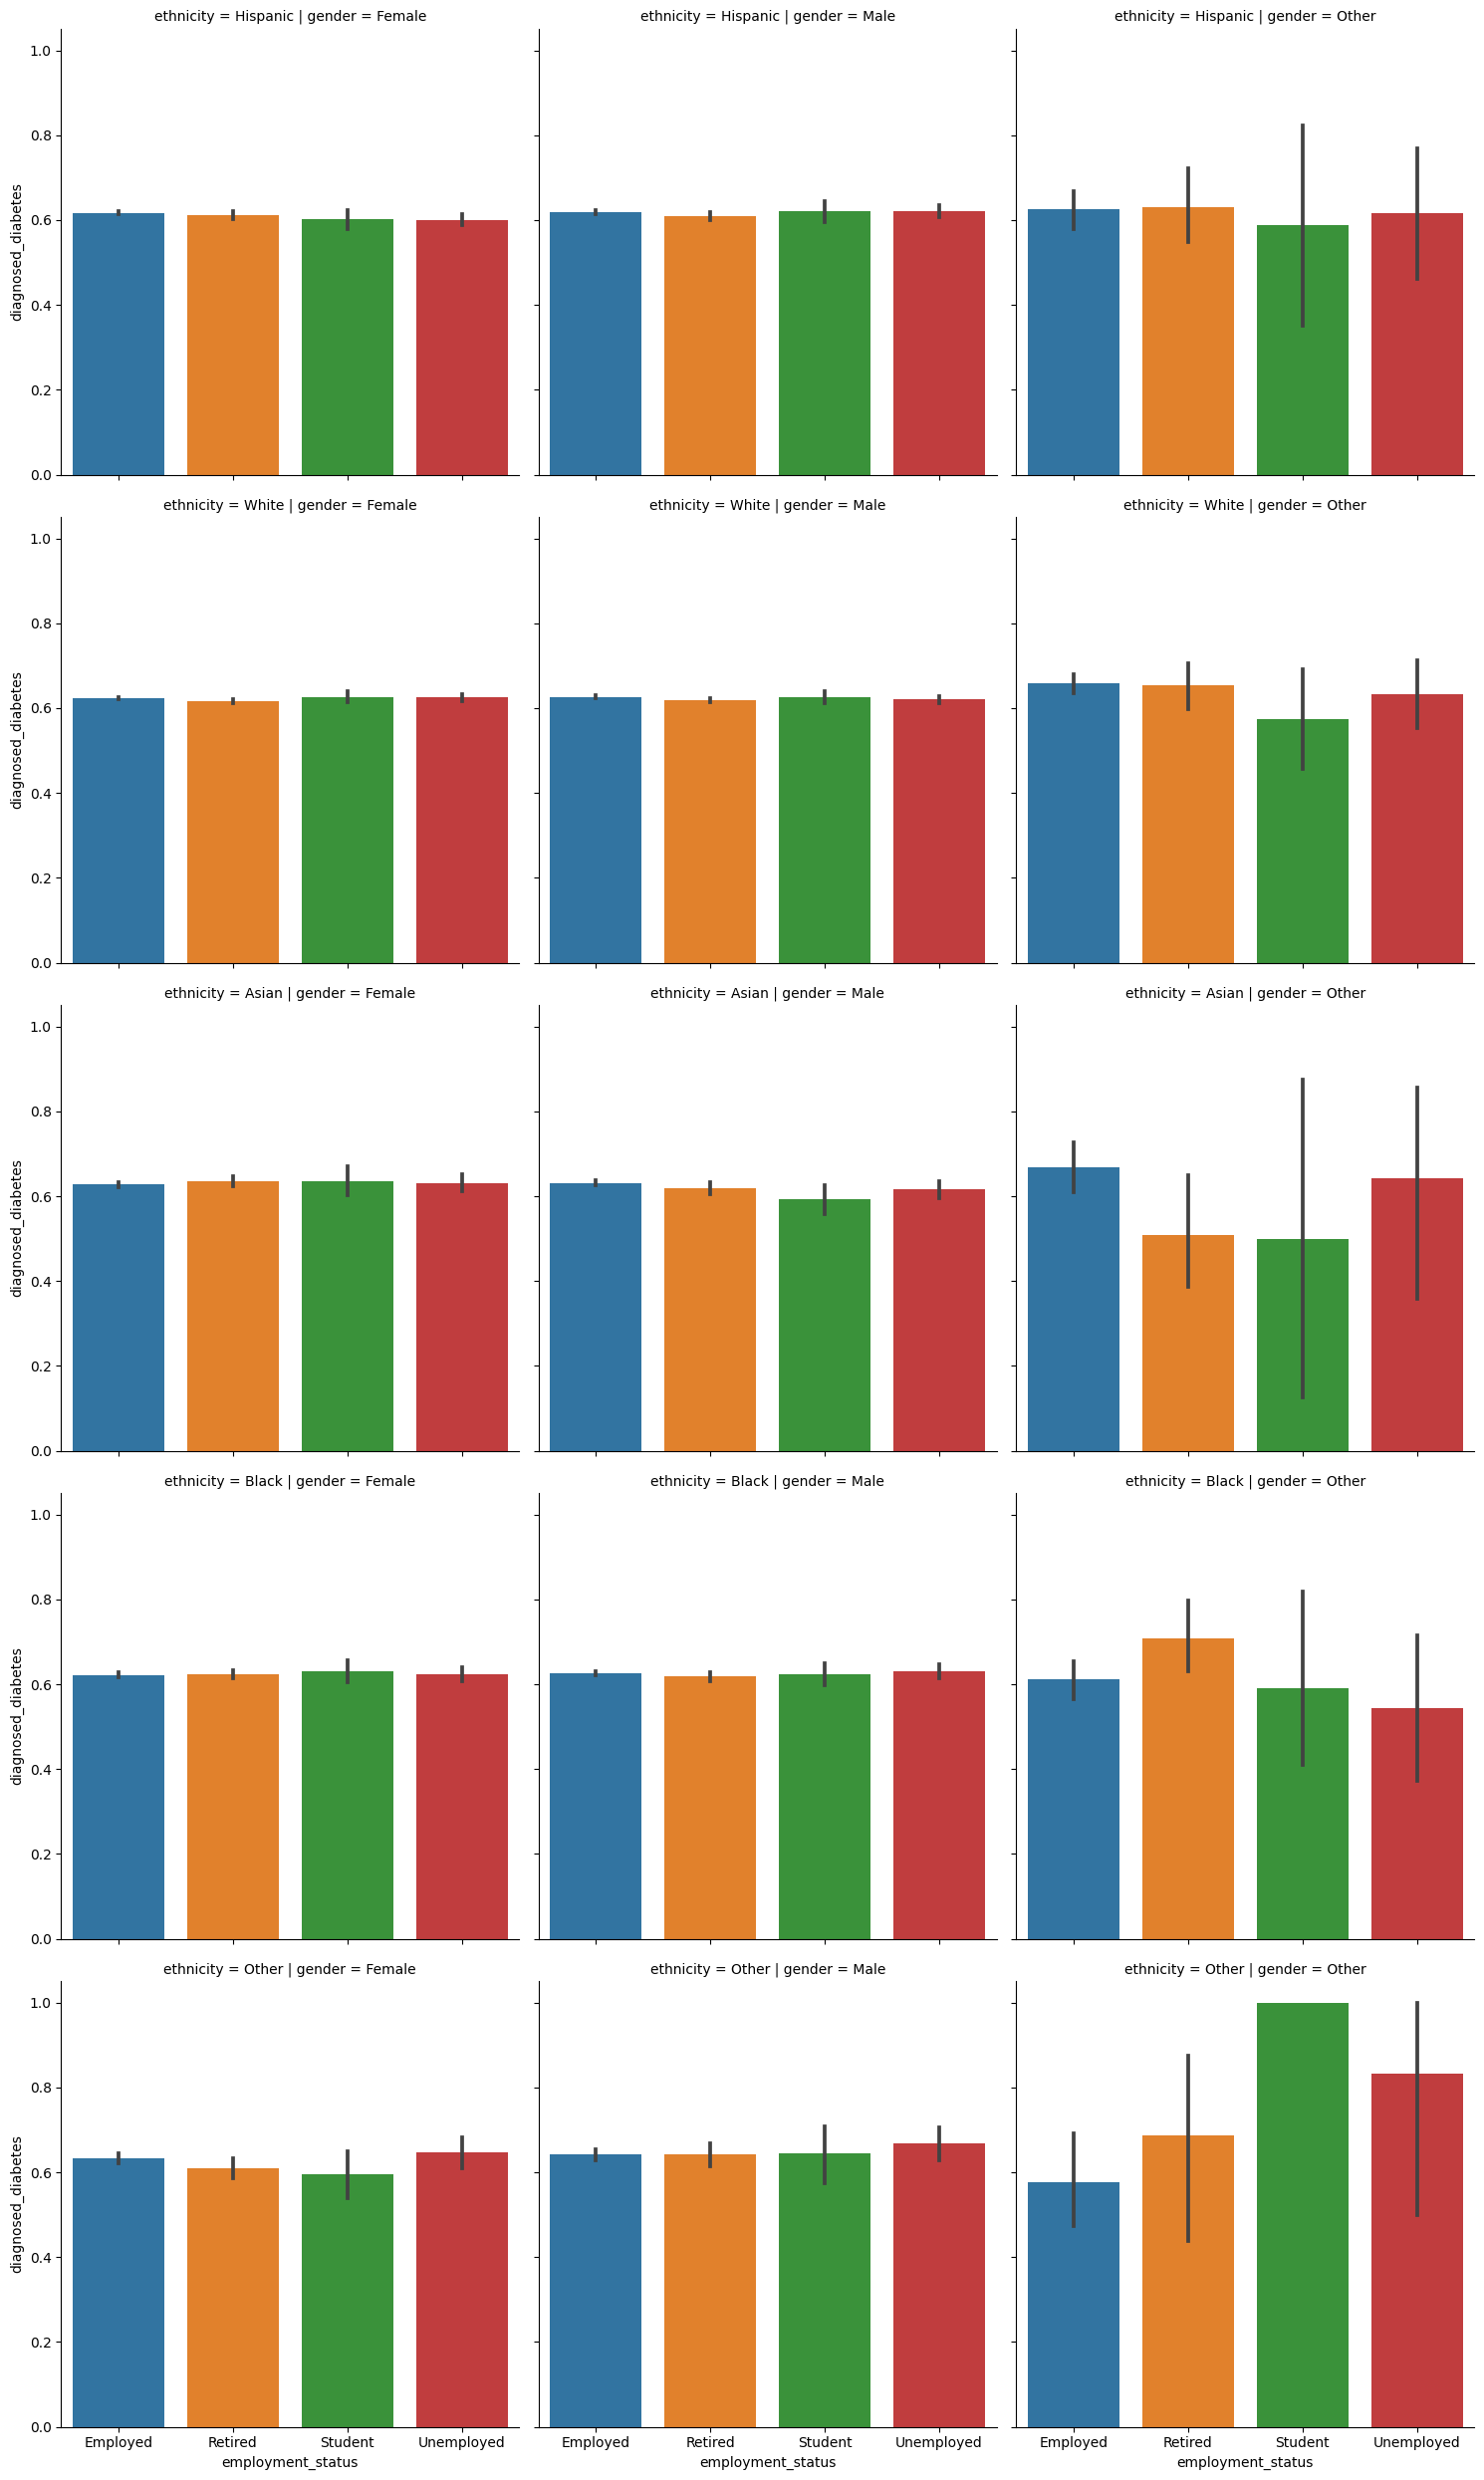

In [218]:
sns.catplot(data=X_train,x='employment_status',y='diagnosed_diabetes',kind='bar',row='ethnicity',col='gender')
plt.show()

In [219]:
X_train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


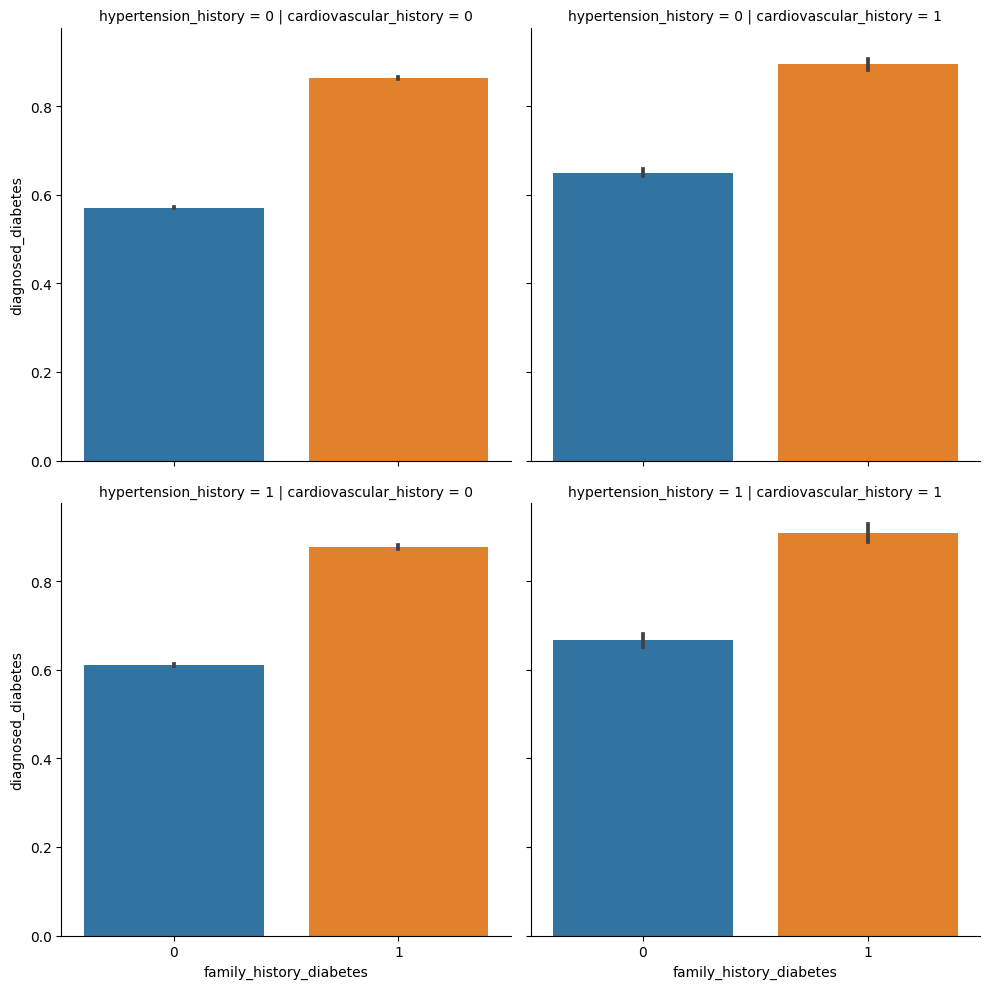

In [220]:
sns.catplot(data=X_train,x='family_history_diabetes',y='diagnosed_diabetes',kind='bar',row='hypertension_history',col='cardiovascular_history')
plt.show()

In [221]:
X_train.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

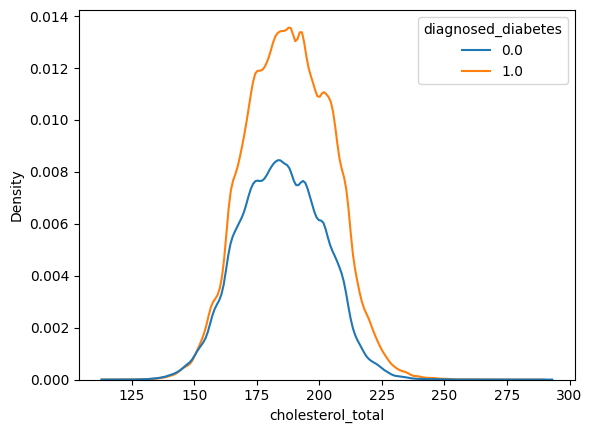

In [222]:
sns.kdeplot(data=X_train,x='cholesterol_total',hue='diagnosed_diabetes')
plt.show()

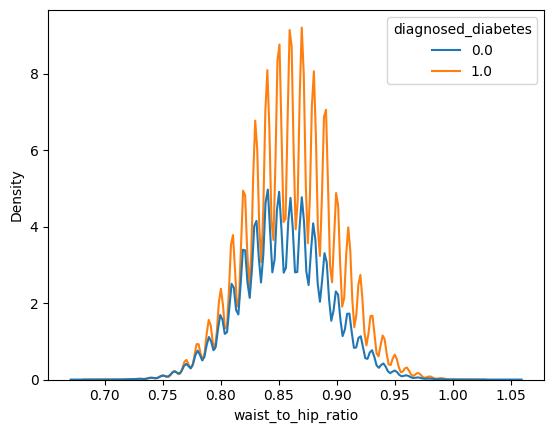

In [223]:
sns.kdeplot(data=X_train,x='waist_to_hip_ratio',hue='diagnosed_diabetes')
plt.show()

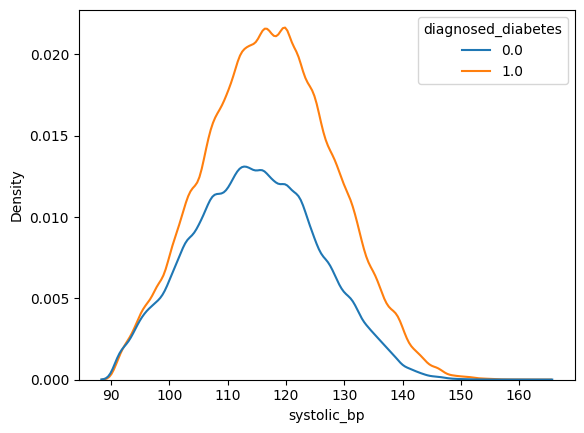

In [224]:
sns.kdeplot(data=X_train,x='systolic_bp',hue='diagnosed_diabetes')
plt.show()

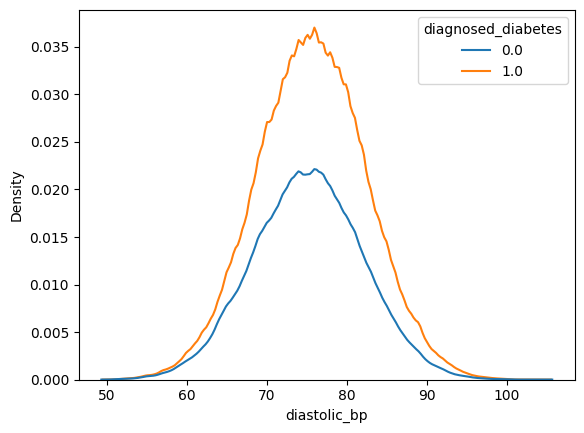

In [225]:
sns.kdeplot(data=X_train,x='diastolic_bp',hue='diagnosed_diabetes')
plt.show()

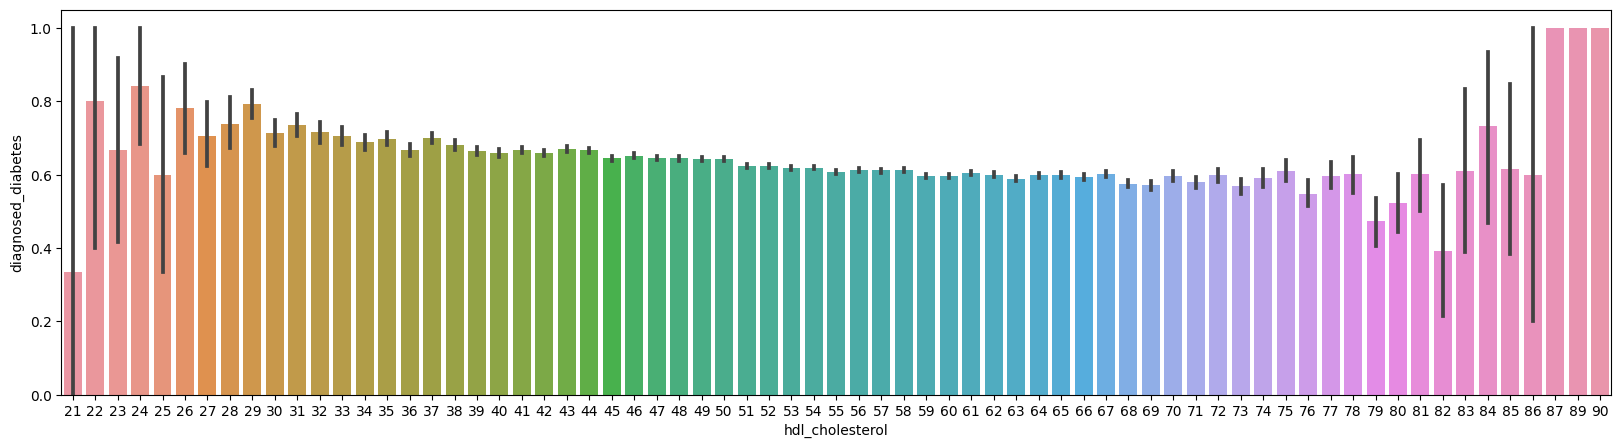

In [226]:
plt.figure(figsize=(20,5))
sns.barplot(data=X_train,x='hdl_cholesterol',y='diagnosed_diabetes')
plt.show()

In [227]:
X_train.groupby(['hdl_cholesterol'])['diagnosed_diabetes'].agg('mean')

hdl_cholesterol
21    0.333333
22    0.800000
23    0.666667
24    0.842105
25    0.600000
        ...   
85    0.615385
86    0.600000
87    1.000000
89    1.000000
90    1.000000
Name: diagnosed_diabetes, Length: 69, dtype: float64

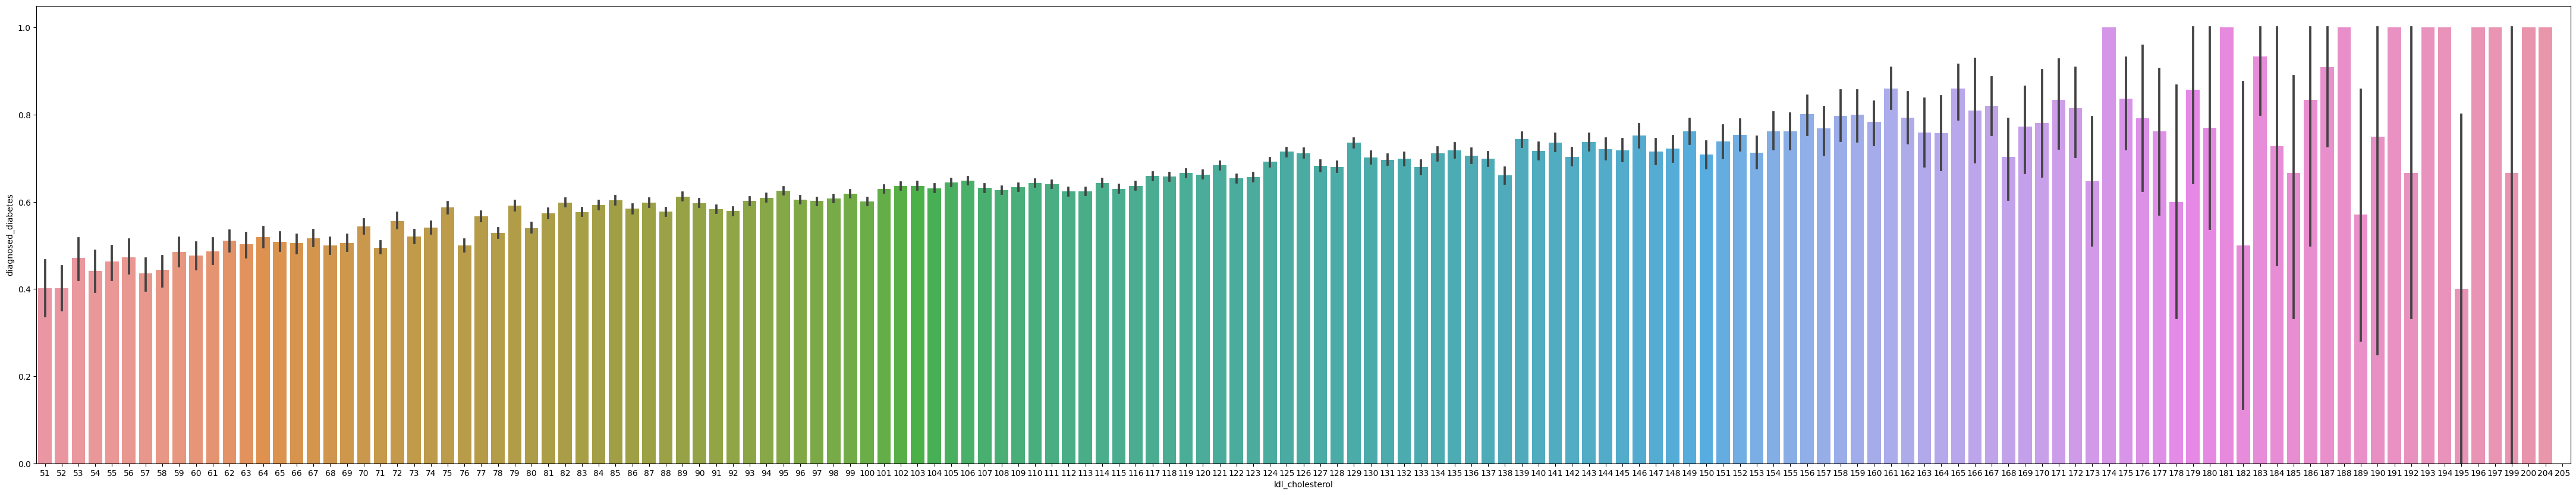

In [228]:
plt.figure(figsize=(55,10))
sns.barplot(data=X_train,x='ldl_cholesterol',y='diagnosed_diabetes')
plt.show()

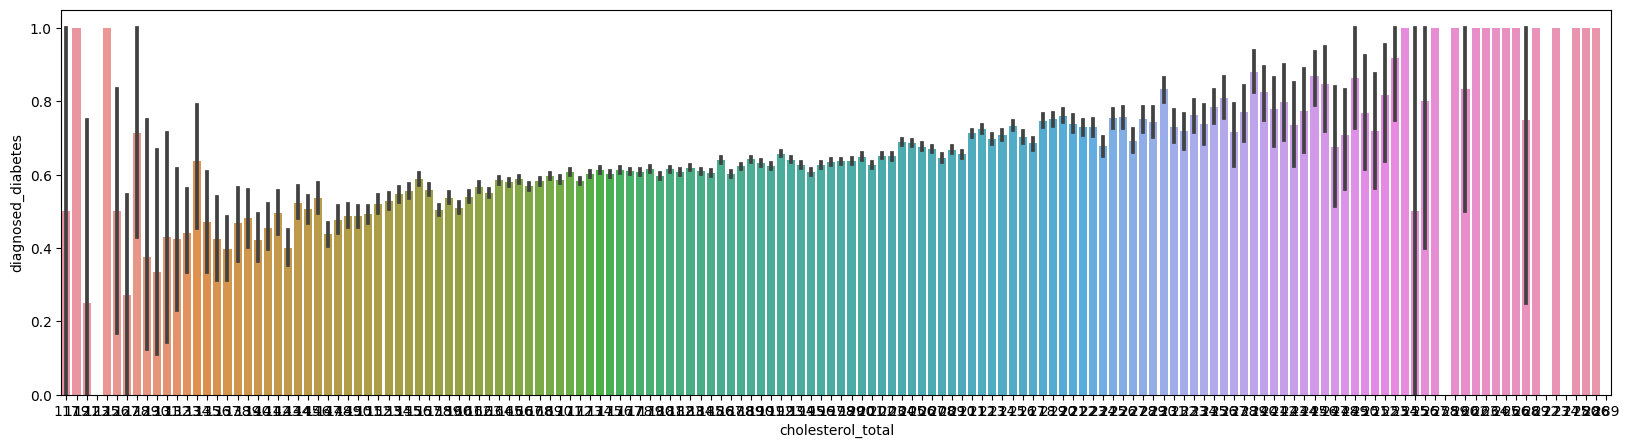

In [229]:
plt.figure(figsize=(20,5))
sns.barplot(data=X_train,x='cholesterol_total',y='diagnosed_diabetes')
plt.show()

In [230]:
# X_train['lifestyle_riskfactor'] = (X_train['alcohol_consumption_per_week']/X_train['alcohol_consumption_per_week'].max()) + (X_train['screen_time_hours_per_day']/X_train['screen_time_hours_per_day'].max()) - (X_train['physical_activity_minutes_per_week']/X_train['physical_activity_minutes_per_week'].max()) - (X_train['sleep_hours_per_day']/X_train['sleep_hours_per_day'].max())
# X_test['lifestyle_riskfactor'] = (X_test['alcohol_consumption_per_week']/X_test['alcohol_consumption_per_week'].max()) + (X_test['screen_time_hours_per_day']/X_test['screen_time_hours_per_day'].max()) - (X_test['physical_activity_minutes_per_week']/X_test['physical_activity_minutes_per_week'].max()) - (X_test['sleep_hours_per_day']/X_test['sleep_hours_per_day'].max())

In [231]:
# X_train['obesity_flag'] = (X_train['bmi']>=30).astype(int)
# X_train['high_tg_flag'] = (X_train['triglycerides']>=150).astype(int)
# X_train['high_bp_flag'] = ((X_train['systolic_bp'] >= 130) | (X_train['diastolic_bp'] >= 85)).astype(int)
# X_train['low_hdl_flag'] = (X_train['hdl_cholesterol'] < 45).astype(int)

# X_test['obesity_flag'] = (X_test['bmi']>=30).astype(int)
# X_test['high_tg_flag'] = (X_test['triglycerides']>=150).astype(int)
# X_test['high_bp_flag'] = ((X_test['systolic_bp'] >= 130) | (X_test['diastolic_bp'] >= 85)).astype(int)
# X_test['low_hdl_flag'] = (X_test['hdl_cholesterol'] < 45).astype(int)

# X_train['metabolic_riskfactor'] = X_train['obesity_flag']+X_train['high_tg_flag']+X_train['high_bp_flag']+X_train['low_hdl_flag']+X_train['hypertension_history']+X_train['cardiovascular_history']+X_train['family_history_diabetes']
# X_test['metabolic_riskfactor'] = X_test['obesity_flag']+X_test['high_tg_flag']+X_test['high_bp_flag']+X_test['low_hdl_flag']+X_test['hypertension_history']+X_test['cardiovascular_history']+X_test['family_history_diabetes']

In [232]:
X_train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


#### PREPROCESSING

We perform the following, 
1. Target encoding of gender, ethnicity, education_level, income_level, smoking_status, employment_status etc. 
2. Binning VLDL level

In [233]:
X_train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [234]:
cat_cols = list(X_train.select_dtypes(include=object))
cat_cols

['gender',
 'ethnicity',
 'education_level',
 'income_level',
 'smoking_status',
 'employment_status']

In [235]:
# perform nested cv leakage-safe target encoding
def Target_Encoding(X_tr,X_test,target_col,cols_to_be_target_enc,n_splits,seed):
    '''
    Perform OOF leakage-safe target encoding to create new features.
    '''
    # dataframes to store encoded columns
    te_train = pd.DataFrame(index=X_tr.index)
    te_test = pd.DataFrame(index=X_test.index)

    y = X_tr[target_col]

    skf = StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed)

    for col in cols_to_be_target_enc:
        oof = np.zeros(len(X_tr),dtype=float)

        for tr_idx,va_idx in skf.split(X_tr,y):
            tr_fold = X_tr.iloc[tr_idx]
            va_fold = X_tr.iloc[va_idx]

            mean_map = tr_fold.groupby(col)[target_col].mean()
            oof[va_idx] = va_fold[col].map(mean_map).astype(float).fillna(0)

        te_train[f'te_{col}'] = oof

        #Global map for test
        global_map = X_tr.groupby(col)[target_col].mean()
        te_test[f'te_{col}'] = X_test[col].map(global_map).astype(float).fillna(0)
    
    return te_train,te_test

In [236]:
tr_bins, bins = pd.qcut(X_train['age'], q=4, labels=False, retbins=True, duplicates='drop') # Young, Middle, Senior, Elderly
X_train['age_group'] = tr_bins
X_test['age_group'] = pd.cut(X_test['age'], bins=bins, labels=False, include_lowest=True) # Young, Middle, Senior, Elderly

In [237]:
# target encode
te_train,te_test = Target_Encoding(X_train,X_test,"diagnosed_diabetes",cat_cols,7,42)

In [238]:
X_train = X_train.join(te_train)
X_test = X_test.join(te_test)
X_train.pop("diagnosed_diabetes")

0         1.0
1         1.0
2         0.0
3         1.0
4         1.0
         ... 
699995    0.0
699996    1.0
699997    1.0
699998    1.0
699999    1.0
Name: diagnosed_diabetes, Length: 700000, dtype: float64

In [239]:
X_train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,family_history_diabetes,hypertension_history,cardiovascular_history,age_group,te_gender,te_ethnicity,te_education_level,te_income_level,te_smoking_status,te_employment_status
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,0,0,0,0,0.622347,0.615292,0.621695,0.626695,0.623980,0.624521
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,0,0,0,1,0.622170,0.624513,0.621609,0.620905,0.623017,0.624501
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,0,0,0,0,0.624492,0.617080,0.621292,0.627279,0.622909,0.618333
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,0,1,0,2,0.622170,0.624513,0.621609,0.626606,0.622212,0.624501
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,0,1,0,2,0.624492,0.623912,0.621292,0.619651,0.622909,0.618333


In [240]:
# remove unwanted columns
X_train.drop(columns=['id'],inplace=True)
X_test.drop(columns=['id'],inplace=True)

In [241]:
num_cols = list(X_train.select_dtypes(include=np.number))
num_cols

['age',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'age_group',
 'te_gender',
 'te_ethnicity',
 'te_education_level',
 'te_income_level',
 'te_smoking_status',
 'te_employment_status']

In [242]:
num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ('num_process',num_pipeline,num_cols)
])

In [243]:
def Preprocessing(X_tr,X_test,target,n_splits,seed):
    '''
    Function to perform OOF preprocessing to ensure robust model evaluation.
    '''
    skf = StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed)
    y= X_tr.pop(target)

    # fit on partial data to infer the shape
    sample_transformed = preprocessing.fit_transform(X_tr.iloc[:len(X_tr)//2,:])
    oof_vals = np.zeros((len(X_tr),sample_transformed.shape[1]))


    for tr_idx,val_idx in skf.split(X_tr,y):
        tr_fold = X_tr.iloc[tr_idx]
        va_fold = X_tr.iloc[val_idx]
        # simp_imputer = SimpleImputer(strategy='median')
        preprocessing.fit(tr_fold)
        oof_vals[val_idx] = preprocessing.transform(va_fold)

    preprocessing.fit(X_tr)
    X_test_transformed = preprocessing.transform(X_test)
    X_test = pd.DataFrame(X_test_transformed,columns=preprocessing.get_feature_names_out(),index=X_test.index)

    X_tr = pd.DataFrame(oof_vals,columns=preprocessing.get_feature_names_out(),index=X_tr.index)
    
    return X_tr,X_test

In [244]:
X_train.columns

Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'age_group', 'te_gender', 'te_ethnicity',
       'te_education_level', 'te_income_level', 'te_smoking_status',
       'te_employment_status'],
      dtype='object')

In [245]:
X_train = X_train.join(ytrain)

In [246]:
X_train_preprocessed,X_test_preprocessed = Preprocessing(X_train,X_test,'diagnosed_diabetes',7,42)

In [247]:
X_train_preprocessed.head()

,num_process__age,num_process__alcohol_consumption_per_week,num_process__physical_activity_minutes_per_week,num_process__diet_score,num_process__sleep_hours_per_day,num_process__screen_time_hours_per_day,num_process__bmi,num_process__waist_to_hip_ratio,num_process__systolic_bp,num_process__diastolic_bp,...,num_process__family_history_diabetes,num_process__hypertension_history,num_process__cardiovascular_history,num_process__age_group,num_process__te_gender,num_process__te_ethnicity,num_process__te_education_level,num_process__te_income_level,num_process__te_smoking_status,num_process__te_employment_status
0,-1.660374,-1.023150,-0.688383,1.186568,-0.224710,0.044218,2.630337,1.875259,-0.389227,-0.796177,...,-0.419293,-0.471344,-0.177108,-1.314084,-0.570963,-2.022158,-0.409977,0.888170,0.730684,0.478168
1,-0.030680,-0.069622,-0.141639,-0.179659,-0.557234,-0.105134,-0.724967,-0.757022,0.336278,0.228087,...,-0.419216,-0.471632,-0.176271,-0.428630,-0.684750,0.301904,-0.430586,-0.631669,-0.318298,0.479072
2,-1.574811,0.885152,1.518192,1.733600,0.441138,1.527456,-0.620076,-0.757253,-1.934049,1.986242,...,-0.419474,-0.471999,-0.176577,-1.314304,0.741903,-1.520370,-0.516886,1.051117,-0.435706,-1.982557
3,0.312524,0.884563,-0.063470,-0.931499,-0.002917,1.575055,0.253520,-0.757022,0.427095,-0.943263,...,-0.419216,2.120298,-0.176271,0.457061,-0.684750,0.301904,-0.430586,0.875340,-1.238277,0.479072
4,0.312755,-1.023168,-0.492500,-0.179741,-0.888917,-0.450775,1.022955,1.085861,-0.753292,-2.262853,...,-0.419474,2.118649,-0.176577,0.457666,0.741903,0.151233,-0.516886,-0.963005,-0.435706,-1.982557


#### CHECKING INFLUENCE OF TRANSFORMED FEATURES ON TARGET VARIABLE

In [248]:
# compute mutual information
# num_cols = list(X_train_preprocessed.select_dtypes(include=np.number))
mi_result=mutual_info_classif(X_train_preprocessed,ytrain)
mi_result = pd.Series(mi_result)
mi_result.index = num_cols
mi_result.sort_values(ascending=False)

physical_activity_minutes_per_week    0.034233
family_history_diabetes               0.029795
age                                   0.014484
age_group                             0.012566
triglycerides                         0.008616
ldl_cholesterol                       0.006652
bmi                                   0.006048
systolic_bp                           0.005932
hypertension_history                  0.005840
te_gender                             0.004677
cholesterol_total                     0.004520
waist_to_hip_ratio                    0.003947
te_employment_status                  0.003897
te_smoking_status                     0.003609
te_income_level                       0.002744
te_education_level                    0.002681
cardiovascular_history                0.002672
te_ethnicity                          0.002226
alcohol_consumption_per_week          0.001549
diastolic_bp                          0.000919
hdl_cholesterol                       0.000908
sleep_hours_p

In [249]:
X_train_preprocessed = X_train_preprocessed.join(ytrain)
corr_res = X_train_preprocessed.corr()
corr_res['diagnosed_diabetes'].sort_values(ascending=False)

diagnosed_diabetes                                 1.000000
num_process__family_history_diabetes               0.211064
num_process__age                                   0.161162
num_process__age_group                             0.144813
num_process__systolic_bp                           0.107132
num_process__bmi                                   0.105580
num_process__ldl_cholesterol                       0.102772
num_process__triglycerides                         0.090635
num_process__cholesterol_total                     0.088112
num_process__waist_to_hip_ratio                    0.081050
num_process__diastolic_bp                          0.036270
num_process__hypertension_history                  0.029979
num_process__cardiovascular_history                0.024744
num_process__heart_rate                            0.023866
num_process__screen_time_hours_per_day             0.018213
num_process__te_education_level                    0.007314
num_process__te_income_level            

In [250]:
X_train_preprocessed.pop("diagnosed_diabetes")

0         1.0
1         1.0
2         0.0
3         1.0
4         1.0
         ... 
699995    0.0
699996    1.0
699997    1.0
699998    1.0
699999    1.0
Name: diagnosed_diabetes, Length: 700000, dtype: float64

### TESTING ML MODELS
Now we run the initial predictors coupled with the engineered ones on the below ML models to see how they perform. 

The models considered are, 
1. Random Forest
2. XGBoost

In [251]:
def oof_auc_check_for_model(X,y,model_pipeline):
    '''
    Function to check for model performance using OOF CV.
    '''
    skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True)
    oof_score = np.zeros(len(X),dtype=float)
    acc_results = []

    for tr_idx,val_idx in skf.split(X,y):
        tr_fold,y_tr = X.iloc[tr_idx],y[tr_idx]
        val_fold,y_val = X.iloc[val_idx],y[val_idx]

        model = clone(model_pipeline)
        
        model.fit(tr_fold,y_tr)
        oof_score[val_idx] = model.predict_proba(val_fold)[:,1].astype(float)

        fold_pred = oof_score[val_idx]
        acc_score = roc_auc_score(y_val,fold_pred)

        acc_results.append(acc_score)
        
    
    return roc_auc_score(y,oof_score),acc_results

In [252]:
def Learning_Curve(model_pipeline,X_tr,y_tr):
    '''
    Function to plot learning curve for a model.
    '''
    train_sizes,train_scores,valid_scores = learning_curve(model_pipeline,X_tr,y_tr,train_sizes=np.linspace(0.01,1,40),cv=StratifiedKFold(random_state=42,shuffle=True,n_splits=5),scoring='neg_log_loss')
    train_errors = -train_scores.mean(axis=1)
    valid_errors = -valid_scores.mean(axis=1)

    plt.plot(train_sizes,train_errors,"r-+",linewidth=2,label="train")
    plt.plot(train_sizes,valid_errors,"b-+",linewidth=2,label="valid")
    plt.xlabel("Training set size")
    plt.ylabel("Log Loss")
    plt.show()

#### BASELINE XGBOOST MODEL

In [253]:
# try testing on a baseline xgb model which usually performs better than randomforest
baseline_xgb_pipeline = Pipeline([
    ('baseline_xgbmodel',XGBClassifier(objective='binary:logistic',random_state=42))
])

baseline_xgb_result,roc_auc_result = oof_auc_check_for_model(X_train_preprocessed,ytrain,baseline_xgb_pipeline)
print(f'ROC AUC on valid set: {baseline_xgb_result}, ROC AUC mean & std: {np.array(roc_auc_result).mean()} and {np.array(roc_auc_result).std()}')

ROC AUC on valid set: 0.7159740921149764, ROC AUC mean & std: 0.7159824722662054 and 0.003073594862646404


In [254]:
# train baseline xgb model on full dataset to fit parameters
baseline_xgb_pipeline.fit(X_train_preprocessed,ytrain)

y_pred_prob_xgb_base_on_train = baseline_xgb_pipeline.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,y_pred_prob_xgb_base_on_train)}")

roc auc on train set is : 0.743981260720574


In [255]:
# predict on test
y_probpred_test_xgb_base = baseline_xgb_pipeline.predict_proba(X_test_preprocessed)[:,1]

In [256]:
# save results
# df_baseline_xgb_results = pd.DataFrame(data=list(zip(diabetes_test_df['id'],y_probpred_test_xgb_base)),columns=['id','diagnosed_diabetes'])
# df_baseline_xgb_results.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/xgb/XGB_base_0_071225.csv",index=False)

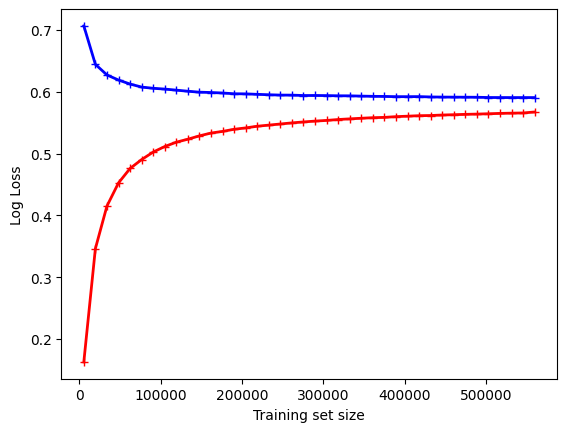

In [257]:
Learning_Curve(baseline_xgb_pipeline,X_train_preprocessed,ytrain)

#### BASELINE RANDOM FOREST

In [258]:
randforest_model = RandomForestClassifier(random_state=42,max_depth=10)

# train & test random forest model using k-fold cv
baseline_randforest_result,oof_result = oof_auc_check_for_model(X_train_preprocessed,ytrain,randforest_model)
print(f'OOF-CV ROC_AUC result is: {baseline_randforest_result}. Foldwise ROC AUC mean & std are: {np.array(oof_result).mean()}, {np.array(oof_result).std()}')

OOF-CV ROC_AUC result is: 0.6983593327849347. Foldwise ROC AUC mean & std are: 0.6983864303694375, 0.0007585171585822734


In [259]:
# train baseline logreg model on full dataset to fit parameters
randforest_model.fit(X_train_preprocessed,ytrain)

y_pred_randforestbase_on_train = randforest_model.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,y_pred_randforestbase_on_train)}")

roc auc on train set is : 0.7105745594851672


#### BASELINE ADABOOST

In [260]:
adaboost_model = AdaBoostClassifier(random_state=42)

# train & test random forest model using k-fold cv
baseline_adaboost_result,oof_result = oof_auc_check_for_model(X_train_preprocessed,ytrain,adaboost_model)
print(f'OOF-CV ROC_AUC result is: {baseline_adaboost_result}. Foldwise mean & std are: {np.array(oof_result).mean()}, {np.array(oof_result).std()}')

OOF-CV ROC_AUC result is: 0.694218653958312. Foldwise mean & std are: 0.6942754359408119, 0.0008027158387421485


In [261]:
# train baseline logreg model on full dataset to fit parameters
adaboost_model.fit(X_train_preprocessed,ytrain)

y_pred_adaboostbase_on_train = adaboost_model.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,y_pred_adaboostbase_on_train)}")

roc auc on train set is : 0.6952457560955495


#### HYPER PARAMETER TUNED XGBoost
We use **Randomised search CV** to come up with the optimal set of hyper parameters for **XGBoost** model.

In [281]:
# fine tunes hyperparameter and sets optimal boosted rounds using fixed early-stopping per fold.
def objective(trial):
    '''
    Function to tune hyper-parameters for xgb model using optuna
    '''
    params = {
        # 'n_estimators':trial.suggest_int('n_estimators',100,2000),
        'colsample_bylevel':trial.suggest_float('colsample_bylevel',0,1),
        'reg_alpha':trial.suggest_float('reg_alpha',0,2),
        'reg_lambda':trial.suggest_float('reg_lambda',0,2),
        'max_depth':trial.suggest_int('max_depth',2,10),
        'tree_method':'hist',
        'device': 'cuda', 
        'random_state': 42,
        'objective' : 'binary:logistic',
        'eval_metric':'auc'
    }

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    model = XGBClassifier(**params,n_estimators = 5000,early_stopping_rounds = 50)
    fold_aucs = []
    best_trees_per_fold = []
    

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

        model.fit(X_tr,y_tr,eval_set=[(X_val,y_val)],verbose=False) # perform evaluation using early-stopping on eval_set

        # collect best val_score per fold
        fold_aucs.append(model.best_score)
        best_trees_per_fold.append(model.best_iteration)
    
    mean_auc = np.array(fold_aucs).mean()
    mean_std = np.array(fold_aucs).std()
    mean_trees = np.array(best_trees_per_fold).mean()

    # log results
    print(f'ROC AUC score - {mean_auc} +- {mean_std} & optimal trees - {mean_trees} +- {np.array(best_trees_per_fold).std()}')
    
    return mean_auc

In [282]:
study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=100)

[I 2025-12-08 18:45:33,325] A new study created in memory with name: no-name-7c57f201-0176-404c-91eb-63f933e664c1
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:45:33] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:45:38] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:45:43] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to C

ROC AUC score - 0.7137551854885108 +- 0.002702692784810538 & optimal trees - 188.6 +- 36.75649602451246


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:46:03] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:46:06] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:46:10] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Librar

ROC AUC score - 0.703981172302404 +- 0.0019140270065091155 & optimal trees - 59.2 +- 4.995998398718719


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:46:20] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:46:29] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:46:43] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Librar

...

ROC AUC score - 0.7050884088699231 +- 0.0020037049469292826 & optimal trees - 62.4 +- 24.434401977539782


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [20:29:05] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [20:29:12] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [20:29:20] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Librar

ROC AUC score - 0.720002198476768 +- 0.0029603362638808903 & optimal trees - 394.4 +- 47.12791105067145


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [20:29:47] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [20:30:00] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [20:30:22] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/Librar

ROC AUC score - 0.7206106406354775 +- 0.0026980222999782315 & optimal trees - 784.0 +- 186.69440270131292


In [284]:
study.best_params

{'colsample_bylevel': 0.9968784910980499,
 'reg_alpha': 1.9317783542624938,
 'reg_lambda': 0.7312742172728528,
 'max_depth': 2}

In [286]:
# train best xgb model above and run predictions
study.best_trial

FrozenTrial(number=51, state=<TrialState.COMPLETE: 1>, values=[0.720933571760687], datetime_start=datetime.datetime(2025, 12, 8, 19, 32, 22, 913909), datetime_complete=datetime.datetime(2025, 12, 8, 19, 33, 56, 608082), params={'colsample_bylevel': 0.9968784910980499, 'reg_alpha': 1.9317783542624938, 'reg_lambda': 0.7312742172728528, 'max_depth': 2}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'colsample_bylevel': FloatDistribution(high=1.0, log=False, low=0.0, step=None), 'reg_alpha': FloatDistribution(high=2.0, log=False, low=0.0, step=None), 'reg_lambda': FloatDistribution(high=2.0, log=False, low=0.0, step=None), 'max_depth': IntDistribution(high=10, log=False, low=2, step=1)}, trial_id=51, value=None)

In [289]:
study.best_value

0.720933571760687

In [290]:
xgb_optimal_params = study.best_params
xgb_optimal_params.update({'n_estimators':int(948.6)})

xgb_optimal_params

{'colsample_bylevel': 0.9968784910980499,
 'reg_alpha': 1.9317783542624938,
 'reg_lambda': 0.7312742172728528,
 'max_depth': 2,
 'n_estimators': 948}

In [291]:
xgb_optimal = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)

optimal_xgb_result,roc_auc_result = oof_auc_check_for_model(X_train_preprocessed,ytrain,xgb_optimal)
print(f'ROC AUC on valid set: {optimal_xgb_result}, ROC AUC mean & std: {np.array(roc_auc_result).mean()} and {np.array(roc_auc_result).std()}')

ROC AUC on valid set: 0.7208402937764927, ROC AUC mean & std: 0.720840034641434 and 0.002829463312986553


In [292]:
# train baseline xgb model on full dataset to fit parameters
xgb_optimal.fit(X_train_preprocessed,ytrain)

xgb_optimal_prob_train = xgb_optimal.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,xgb_optimal_prob_train)}")

roc auc on train set is : 0.7276469084944888


In [293]:
# predict on test
xgb_optimal_prob = xgb_optimal.predict_proba(X_test_preprocessed)[:,1]

In [294]:
# save results
# df_baseline_xgb_results = pd.DataFrame(data=list(zip(diabetes_test_df['id'],xgb_optimal_prob)),columns=['id','diagnosed_diabetes'])
# df_baseline_xgb_results.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/xgb/XGB_optimal_2_081225.csv",index=False)

The above optuna-led hyperparameter tuned xgboost model yields an ROC AUC - 0.69615

#### HYPER PARAMETER TUNING FOR LGBM
Here we tune hyperparameters for LGBM using OPTUNA

In [303]:
# fine tunes hyperparameter and sets optimal boosted rounds using fixed early-stopping per fold.
def objective_lgbm(trial):
    '''
    Function to tune hyper-parameters for LGBM model using optuna
    '''
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'min_split_gain': trial.suggest_float('min_split_gain', 0, 0.5),
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'force_col_wise': True
    }

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    fold_aucs = []
    best_iters = []
    

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

        # lgbm dataset
        train_data = lgb.Dataset(data=X_tr,label=y_tr)
        valid_data = lgb.Dataset(data=X_val,label=y_val,reference=train_data)

        # set model
        model = lgb.train(
            params,
            train_data,
            valid_sets=[valid_data],
            num_boost_round=2000,
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),lgb.log_evaluation(0)]
        )
        
        # collect best val_score per fold
        fold_aucs.append(model.best_score['valid_0']['auc'])
        best_iters.append(model.best_iteration)
    
    mean_auc = np.array(fold_aucs).mean()
    mean_std = np.array(fold_aucs).std()
    mean_trees = np.array(best_iters).mean()

    # log results
    print(f'ROC AUC score - {mean_auc} +- {mean_std} & optimal trees - {mean_trees} +- {np.array(best_iters).std()}')
    
    return mean_auc

In [304]:
study = optuna.create_study(direction='maximize',pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20))
study.optimize(objective_lgbm,n_trials=100)

[I 2025-12-08 23:38:05,870] A new study created in memory with name: no-name-b9e14290-ba64-4c94-bdd5-4d174a70746f
[I 2025-12-08 23:38:26,590] Trial 0 finished with value: 0.7187765718596326 and parameters: {'num_leaves': 131, 'max_depth': 7, 'learning_rate': 0.2650741583828122, 'subsample': 0.867761588539304, 'colsample_bytree': 0.730126639254652, 'min_child_samples': 83, 'reg_alpha': 1.1374901015505134, 'reg_lambda': 1.5304627569390319, 'min_split_gain': 0.2655879044340911}. Best is trial 0 with value: 0.7187765718596326.


ROC AUC score - 0.7187765718596326 +- 0.001546086318154516 & optimal trees - 95.6 +- 8.309031231136396


[I 2025-12-08 23:40:04,832] Trial 1 finished with value: 0.7223258588395463 and parameters: {'num_leaves': 115, 'max_depth': 3, 'learning_rate': 0.08391114793674759, 'subsample': 0.6804374338297987, 'colsample_bytree': 0.8319586068652068, 'min_child_samples': 41, 'reg_alpha': 1.9728904068810968, 'reg_lambda': 1.8110120008867607, 'min_split_gain': 0.08252774811278696}. Best is trial 1 with value: 0.7223258588395463.


ROC AUC score - 0.7223258588395463 +- 0.0016947955132071853 & optimal trees - 1568.2 +- 232.6459971716685


[I 2025-12-08 23:40:42,245] Trial 2 finished with value: 0.7213962703348367 and parameters: {'num_leaves': 38, 'max_depth': 6, 'learning_rate': 0.1063503539741493, 'subsample': 0.9234358768111577, 'colsample_bytree': 0.5182335237236881, 'min_child_samples': 27, 'reg_alpha': 0.1881519908633642, 'reg_lambda': 0.2920020257808622, 'min_split_gain': 0.24275037024908352}. Best is trial 1 with value: 0.7223258588395463.


...

ROC AUC score - 0.7219626601542724 +- 0.001919365084310069 & optimal trees - 765.0 +- 95.57614765201619


[I 2025-12-09 01:16:16,013] Trial 98 finished with value: 0.7223818804568352 and parameters: {'num_leaves': 37, 'max_depth': 3, 'learning_rate': 0.09700962002516203, 'subsample': 0.5333178495987975, 'colsample_bytree': 0.5251118492871539, 'min_child_samples': 32, 'reg_alpha': 0.2529157684855759, 'reg_lambda': 1.0364947054082816, 'min_split_gain': 0.2495576247025097}. Best is trial 95 with value: 0.7225927909729333.


ROC AUC score - 0.7223818804568352 +- 0.001976315685675703 & optimal trees - 1527.4 +- 289.30717239639944


[I 2025-12-09 01:18:03,034] Trial 99 finished with value: 0.7226182182994269 and parameters: {'num_leaves': 44, 'max_depth': 3, 'learning_rate': 0.07473071601915962, 'subsample': 0.512981884201985, 'colsample_bytree': 0.5495174740591117, 'min_child_samples': 34, 'reg_alpha': 1.4781440863905424, 'reg_lambda': 0.3743877653288621, 'min_split_gain': 0.35924549599260897}. Best is trial 99 with value: 0.7226182182994269.


ROC AUC score - 0.7226182182994269 +- 0.0018076926266138661 & optimal trees - 1914.8 +- 36.831508250409726


In [305]:
study.best_params

{'num_leaves': 44,
 'max_depth': 3,
 'learning_rate': 0.07473071601915962,
 'subsample': 0.512981884201985,
 'colsample_bytree': 0.5495174740591117,
 'min_child_samples': 34,
 'reg_alpha': 1.4781440863905424,
 'reg_lambda': 0.3743877653288621,
 'min_split_gain': 0.35924549599260897}

In [306]:
study.best_value

0.7226182182994269

In [308]:
study.best_trial

FrozenTrial(number=99, state=<TrialState.COMPLETE: 1>, values=[0.7226182182994269], datetime_start=datetime.datetime(2025, 12, 9, 1, 16, 16, 14490), datetime_complete=datetime.datetime(2025, 12, 9, 1, 18, 3, 33910), params={'num_leaves': 44, 'max_depth': 3, 'learning_rate': 0.07473071601915962, 'subsample': 0.512981884201985, 'colsample_bytree': 0.5495174740591117, 'min_child_samples': 34, 'reg_alpha': 1.4781440863905424, 'reg_lambda': 0.3743877653288621, 'min_split_gain': 0.35924549599260897}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'num_leaves': IntDistribution(high=150, log=False, low=20, step=1), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=False, low=0.01, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'min_child_samples': IntDistribution(high=100, log=False, low=10,

In [309]:
lgbm_optimal_params = study.best_params
lgbm_optimal_params.update({'n_estimators':int(1914.8)})

lgbm_optimal_params

{'num_leaves': 44,
 'max_depth': 3,
 'learning_rate': 0.07473071601915962,
 'subsample': 0.512981884201985,
 'colsample_bytree': 0.5495174740591117,
 'min_child_samples': 34,
 'reg_alpha': 1.4781440863905424,
 'reg_lambda': 0.3743877653288621,
 'min_split_gain': 0.35924549599260897,
 'n_estimators': 1914}

In [311]:
lgbm_optimal = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)

optimal_lgbm_result,roc_auc_result = oof_auc_check_for_model(X_train_preprocessed,ytrain,lgbm_optimal)
print(f'ROC AUC on valid set: {optimal_lgbm_result}, ROC AUC mean & std: {np.array(roc_auc_result).mean()} and {np.array(roc_auc_result).std()}')

ROC AUC on valid set: 0.7225960554113287, ROC AUC mean & std: 0.7225898891070525 and 0.0018050668341844294


In [312]:
# train baseline xgb model on full dataset to fit parameters
lgbm_optimal.fit(X_train_preprocessed,ytrain)

lgbm_optimal_prob_train = lgbm_optimal.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,lgbm_optimal_prob_train)}")

roc auc on train set is : 0.7319550471429366


In [313]:
# predict on test
lgbm_optimal_prob = lgbm_optimal.predict_proba(X_test_preprocessed)[:,1]

In [315]:
# save results
# df_lgbm_optimal_results = pd.DataFrame(data=list(zip(diabetes_test_df['id'],lgbm_optimal_prob)),columns=['id','diagnosed_diabetes'])
# df_lgbm_optimal_results.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/lgbm/lgbm_optimal_0_091225.csv",index=False)

#### HYPER PARAMETER TUNING FOR HISTGRADIENTBOOSTCLASSIFIER
We use **HistGradientBoostClassifier** model to at first have its parameters tuned alongside finding the optimal set of boosted trees for the optimal set of hyper-parameters using **OPTUNA**.

In [349]:
def histboost_objective(trial):
    '''
    Function to come up with suitable set of hyper-parameters and its corresponding optimal boosted rounds using early stopping with optuna for HistGradientBoostingClassifier.
    '''

    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True), # perform dense sampling focusing on regions where performance tends to increase.
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 255),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 200),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-8, 1.0, log=True),
        "max_iter": 5000,                       # set maximum limit to number of boosted trees possible
        "early_stopping": True,                 # enable early stopping
        "n_iter_no_change": 50,                 # early stopping rounds for each CV run.
        "tol": 1e-7,                            # For every CV run and within it for every set of early stopping rounds this sets a boundary as to when to consider an improvement to carry out more trainings.
        "random_state": 42,
        'scoring':'roc_auc',
        'verbose':False
    }

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    fold_aucs = []
    best_iter = []

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx] 

        # define new model and fit to train fold
        model = HistGradientBoostingClassifier(**params)
        model.fit(X=X_tr,y=y_tr,X_val=X_val,y_val=y_val)            # early stopping happens here on (X_val,y_val)

        # run prediction on val fold with each hyper-parameter combination & optimal set of trees obtained using early-stopping and collect roc_auc result per fold
        fold_prob = model.predict_proba(X_val)[:,1]             
        fold_auc = roc_auc_score(y_val,fold_prob)

        fold_aucs.append(fold_auc)
        best_iter.append(model.n_iter_)     # collect optimal set of boosted trees used that gives the best roc_auc on val_set.
    
    mean_roc_auc = np.array(fold_aucs).mean()
    std_roc_auc = np.array(fold_aucs).std()
    mean_trees = np.array(best_iter).mean()

    print(f'ROC AUC - {mean_roc_auc} +- {std_roc_auc} & optimal trees - {mean_trees} +- {np.array(best_iter).std()}')

    return mean_roc_auc # optuna tries to maximize this 

In [350]:
study = optuna.create_study(direction='maximize',pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20))
study.optimize(histboost_objective,n_trials=100,show_progress_bar=True)

[I 2025-12-11 10:08:12,492] A new study created in memory with name: no-name-537839de-0085-44d5-9e06-29121b86134d


  0%|          | 0/100 [00:00<?, ?it/s]

ROC AUC - 0.713242455228412 +- 0.003669998779817877 & optimal trees - 90.0 +- 4.732863826479693
[I 2025-12-11 10:08:55,120] Trial 0 finished with value: 0.713242455228412 and parameters: {'learning_rate': 0.2846880043708383, 'max_depth': 9, 'max_leaf_nodes': 120, 'min_samples_leaf': 134, 'l2_regularization': 4.146344337077203e-08}. Best is trial 0 with value: 0.713242455228412.
ROC AUC - 0.7154771754615734 +- 0.003918969450183563 & optimal trees - 121.6 +- 15.932357013323546
[I 2025-12-11 10:09:38,354] Trial 1 finished with value: 0.7154771754615734 and parameters: {'learning_rate': 0.25723620466997155, 'max_depth': 10, 'max_leaf_nodes': 52, 'min_samples_leaf': 58, 'l2_regularization': 6.683560989855381e-05}. Best is trial 1 with value: 0.7154771754615734.
ROC AUC - 0.7196708230207249 +- 0.004290678389640708 & optimal trees - 960.4 +- 171.75633903876735
[I 2025-12-11 10:15:03,068] Trial 2 finished with value: 0.7196708230207249 and parameters: {'learning_rate': 0.034943472961657916, 'm

In [351]:
study.best_params

{'learning_rate': 0.09699851846923142,
 'max_depth': 3,
 'max_leaf_nodes': 71,
 'min_samples_leaf': 75,
 'l2_regularization': 0.0009156154993603904}

In [352]:
study.best_value

0.7201986605834823

In [353]:
study.best_trial

FrozenTrial(number=73, state=<TrialState.COMPLETE: 1>, values=[0.7201986605834823], datetime_start=datetime.datetime(2025, 12, 11, 22, 44, 21, 630345), datetime_complete=datetime.datetime(2025, 12, 11, 22, 50, 25, 106047), params={'learning_rate': 0.09699851846923142, 'max_depth': 3, 'max_leaf_nodes': 71, 'min_samples_leaf': 75, 'l2_regularization': 0.0009156154993603904}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'learning_rate': FloatDistribution(high=0.3, log=True, low=0.01, step=None), 'max_depth': IntDistribution(high=10, log=False, low=2, step=1), 'max_leaf_nodes': IntDistribution(high=255, log=False, low=15, step=1), 'min_samples_leaf': IntDistribution(high=200, log=False, low=10, step=1), 'l2_regularization': FloatDistribution(high=1.0, log=True, low=1e-08, step=None)}, trial_id=73, value=None)

In [357]:
histgradboost_optimal_params = study.best_params
histgradboost_optimal_params.update({'max_iter':816})

histgradboost_optimal_params

{'learning_rate': 0.09699851846923142,
 'max_depth': 3,
 'max_leaf_nodes': 71,
 'min_samples_leaf': 75,
 'l2_regularization': 0.0009156154993603904,
 'max_iter': 816}

In [358]:
histgradboost_optimal = HistGradientBoostingClassifier(**histgradboost_optimal_params)

optimal_histgradboost_result,roc_auc_result = oof_auc_check_for_model(X_train_preprocessed,ytrain,histgradboost_optimal)
print(f'ROC AUC on valid set: {optimal_histgradboost_result}, ROC AUC mean & std: {np.array(roc_auc_result).mean()} and {np.array(roc_auc_result).std()}')

ROC AUC on valid set: 0.7184057938087638, ROC AUC mean & std: 0.7184142340723148 and 0.004432585875572167


In [359]:
# train baseline xgb model on full dataset to fit parameters
histgradboost_optimal.fit(X_train_preprocessed,ytrain)

histgradboost_optimal_prob_train = histgradboost_optimal.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,histgradboost_optimal_prob_train)}")

roc auc on train set is : 0.7269222564422166


In [360]:
# predict on test
histgradboost_optimal_prob = histgradboost_optimal.predict_proba(X_test_preprocessed)[:,1]

In [361]:
# save results
# df_histgradboost_optimal_results = pd.DataFrame(data=list(zip(diabetes_test_df['id'],histgradboost_optimal_prob)),columns=['id','diagnosed_diabetes'])
# df_histgradboost_optimal_results.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/histgradboost/histgradboost_optimal_0_121225.csv",index=False)

#### USING OPTUNA TO FIND SUITABLE WEIGHT FOR LGBM & XGB & HISTGRADBOOST TO IMPROVE MODEL PERFORMANCE
Here we use OPTUNA to improve model performance by weighing predictions on a 5-fold shuffled stratified CV from both LGBM & XGB.

In [362]:
# --- Optimization Function (Maximize AUC) ---
def optimize_weight(trial):
    # Suggest weights for each model between 0 and 1
    w_xgb = trial.suggest_float('xgb_weight', 0.0, 1.0)
    w_lgb = trial.suggest_float('lgb_weight', 0.0, 1.0)
    w_histgradboost = trial.suggest_float('histgradboost_weight', 0.0, 1.0)

    total_weight = w_xgb + w_lgb + w_histgradboost
    if total_weight == 0:
        return 0.5  # Return neutral AUC if all weights are zero

    # Normalize weights so they sum to 1
    w_xgb /= total_weight
    w_lgb /= total_weight
    w_histgradboost /= total_weight

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    fold_auc = []

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

        # fit optimised cloned xgb & lgb models on train folds & predict on val folds using weights
        lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
        xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
        histgradboost_optimal_model = HistGradientBoostingClassifier(**histgradboost_optimal_params)

        lgb_optimal_model.fit(X_tr,y_tr)
        xgb_optimal_model.fit(X_tr,y_tr)
        histgradboost_optimal_model.fit(X_tr,y_tr)

        lgbm_prob_pred = lgb_optimal_model.predict_proba(X_val)[:,1]
        xgb_prob_pred = xgb_optimal_model.predict_proba(X_val)[:,1]
        histgradboost_prob_pred = histgradboost_optimal_model.predict_proba(X_val)[:,1]

        weighted_prob = w_xgb*xgb_prob_pred + w_lgb*lgbm_prob_pred + w_histgradboost*histgradboost_prob_pred

        try:
            roc_auc_fold = roc_auc_score(y_val,weighted_prob)
        except:
            roc_auc_fold = 0.5

        fold_auc.append(roc_auc_fold)
    
    mean_roc_auc = np.array(fold_auc).mean()
    std_roc_auc = np.array(fold_auc).std()

    print(f'ROC AUC mean - {mean_roc_auc} +- {std_roc_auc}')

    return mean_roc_auc  # Optuna will attempt to maximize this

In [363]:
study = optuna.create_study(direction='maximize')
study.optimize(optimize_weight, n_trials=50, show_progress_bar=True)

[I 2025-12-12 10:00:11,779] A new study created in memory with name: no-name-ca0494ec-ccaf-4aa1-96e7-7af07e128de4


  0%|          | 0/50 [00:00<?, ?it/s]

ROC AUC mean - 0.7220025988032687 +- 0.0017625502098696196
[I 2025-12-12 10:02:54,085] Trial 0 finished with value: 0.7220025988032687 and parameters: {'xgb_weight': 0.7624092814744831, 'lgb_weight': 0.30010568405726434, 'histgradboost_weight': 0.6911452591285489}. Best is trial 0 with value: 0.7220025988032687.
ROC AUC mean - 0.7218802430003821 +- 0.0018621237370038464
[I 2025-12-12 10:05:21,933] Trial 1 finished with value: 0.7218802430003821 and parameters: {'xgb_weight': 0.8700684405788871, 'lgb_weight': 0.369699747684632, 'histgradboost_weight': 0.7530381353740484}. Best is trial 0 with value: 0.7220025988032687.
ROC AUC mean - 0.7220337985962589 +- 0.0017203332079405347
[I 2025-12-12 10:07:54,757] Trial 2 finished with value: 0.7220337985962589 and parameters: {'xgb_weight': 0.7515284085709132, 'lgb_weight': 0.28975156265766844, 'histgradboost_weight': 0.5458767415409044}. Best is trial 2 with value: 0.7220337985962589.
ROC AUC mean - 0.7222581527348071 +- 0.001915703086923081
[I

In [364]:
best_w_xgb = study.best_params['xgb_weight']
best_w_lgb = study.best_params['lgb_weight']
best_w_histgradboost = study.best_params['histgradboost_weight']

In [365]:
best_w_xgb,best_w_lgb,best_w_histgradboost

(0.36194034055752855, 0.6106506912286614, 0.002049462538764174)

In [366]:
study.best_value

0.7231050985635789

In [367]:
# predict using the computed weights above
total_weight = best_w_xgb + best_w_lgb + best_w_histgradboost
best_w_xgb /= total_weight
best_w_lgb /= total_weight
best_w_histgradboost /= total_weight

# check performance on train
pred_prob_on_train = xgb_optimal_prob_train*best_w_xgb + lgbm_optimal_prob_train*best_w_lgb + histgradboost_optimal_prob_train*best_w_histgradboost

try:
    best_auc = roc_auc_score(ytrain, pred_prob_on_train)
except ValueError:
    best_auc = 0.5

print(f'Best optimal ROC AUC performance on train set is: {best_auc}')

Best optimal ROC AUC performance on train set is: 0.7311983750148554


In [368]:
xgb_lgb_histboostgrad_blend_prob = xgb_optimal_prob*best_w_xgb + lgbm_optimal_prob*best_w_lgb + histgradboost_optimal_prob*best_w_histgradboost

In [369]:
# save blend result
# df_xgb_lgb_histgradboost_blend_result = pd.DataFrame(data=list(zip(diabetes_test_df['id'],xgb_lgb_histboostgrad_blend_prob)),columns=['id','diagnosed_diabetes'])
# df_xgb_lgb_histgradboost_blend_result.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/prob_blend_models/xgb_lgb_histgradboost_blend_0_121225.csv",index=False)

#### MICRO-SWEEP AROUND MEAN OPTIMISED ESTIMATORS
Here we run a macro-sweep around mean optimized estimators for each **XGB,LGB & HISTGRADBOOST** models to find the best estimators that yields the highest performance since earlier we setup our tuned models considering the mean estimators for each. 

Idea: 
1. For each tuned model we check 10 possible estimators around the mean for performance improvement above the mean and select that as the estimator. 
2. Next we perform Probability Blending as above with optimized weights. 

In [410]:
xgb_candidates = []
lgb_candidates = []
histgradboost_candidates = []

xgb_mean_trees = xgb_optimal_params['n_estimators']
lgb_mean_trees = lgbm_optimal_params['n_estimators']
histgradboost_mean_trees = histgradboost_optimal_params['max_iter']

# store optimal set of boosted rounds around the mean
# XGB
for num in range(1,10):
    xgb_candidates.append(xgb_mean_trees-num)
    xgb_candidates.append(xgb_mean_trees+num)

    lgb_candidates.append(lgb_mean_trees-num)
    lgb_candidates.append(lgb_mean_trees+num)

    histgradboost_candidates.append(histgradboost_mean_trees-num)
    histgradboost_candidates.append(histgradboost_mean_trees+num)

xgb_candidates.append(xgb_mean_trees)
lgb_candidates.append(lgb_mean_trees)
histgradboost_candidates.append(histgradboost_mean_trees)

In [411]:
xgb_mean_trees

948

In [412]:
def Check_For_Improved_Performance_Around_Mean_Trees(boosted_trees_list,model_tuned_params,model_name):
    '''
    Function that returns the best set of boosted trees for any tuned model around mean number of boosted trees using stratified shuffled 5-fold CV across XGB,LGBM & HistGradBoost Classifiers
    '''
    best_roc_auc = -1.0
    best_rounds = None

    skf_cv = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)

    for tree in tqdm(boosted_trees_list):
        proba_per_tree = np.zeros(len(X_train_preprocessed))
        for tr_idx,val_idx in skf_cv.split(X_train_preprocessed,ytrain):

            X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
            X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

            if model_name in ['XGB','LGBM']:
                model_tuned_params['n_estimators'] = tree

                if model_name == 'XGB':
                    model = XGBClassifier(**model_tuned_params)
                else:
                    model = LGBMClassifier(**model_tuned_params)
            else:
                model_tuned_params['max_iter'] = tree
                model = HistGradientBoostingClassifier(**model_tuned_params)
            
            # fit model
            model.fit(X_tr,y_tr)

            # predict
            pred_proba = model.predict_proba(X_val)[:,1]
            proba_per_tree[val_idx] = pred_proba
        
        tree_wise_roc_auc_score = roc_auc_score(ytrain,proba_per_tree)

        if tree_wise_roc_auc_score>best_roc_auc:
            best_roc_auc = tree_wise_roc_auc_score
            best_rounds = tree
            # print(f'Best round is : {best_rounds},Best ROC AUC is: {best_roc_auc}')
    
    return best_roc_auc,best_rounds

In [413]:
# check for XGB
xgb_best_roc_auc,xgb_best_boosted_rounds = Check_For_Improved_Performance_Around_Mean_Trees(xgb_candidates,xgb_optimal_params,'XGB')

100%|██████████| 19/19 [06:54<00:00, 21.81s/it]


In [415]:
xgb_optimal_params['n_estimators'] = xgb_best_boosted_rounds
xgb_optimal_params

{'colsample_bylevel': 0.9968784910980499,
 'reg_alpha': 1.9317783542624938,
 'reg_lambda': 0.7312742172728528,
 'max_depth': 2,
 'n_estimators': 953}

In [416]:
xgb_optimized = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)

optimized_xgb_result,roc_auc_result = oof_auc_check_for_model(X_train_preprocessed,ytrain,xgb_optimized)
print(f'ROC AUC on valid set: {optimized_xgb_result}, ROC AUC mean & std: {np.array(roc_auc_result).mean()} and {np.array(roc_auc_result).std()}')

ROC AUC on valid set: 0.7208541533830131, ROC AUC mean & std: 0.7208539012152639 and 0.0028363102486246884


In [417]:
# train baseline xgb model on full dataset to fit parameters
xgb_optimized.fit(X_train_preprocessed,ytrain)

xgb_optimized_prob_train = xgb_optimized.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,xgb_optimized_prob_train)}")

roc auc on train set is : 0.7276735359969929


In [418]:
# check for lgbm
lgb_best_roc_auc,lgb_best_boosted_rounds = Check_For_Improved_Performance_Around_Mean_Trees(lgb_candidates,lgbm_optimal_params,'LGBM')

100%|██████████| 19/19 [25:37<00:00, 80.94s/it]


In [419]:
lgbm_optimal_params['n_estimators'] = lgb_best_boosted_rounds
lgbm_optimal_params

{'num_leaves': 44,
 'max_depth': 3,
 'learning_rate': 0.07473071601915962,
 'subsample': 0.512981884201985,
 'colsample_bytree': 0.5495174740591117,
 'min_child_samples': 34,
 'reg_alpha': 1.4781440863905424,
 'reg_lambda': 0.3743877653288621,
 'min_split_gain': 0.35924549599260897,
 'n_estimators': 1922}

In [420]:
lgbm_optimized = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)

optimaised_lgbm_result,roc_auc_result = oof_auc_check_for_model(X_train_preprocessed,ytrain,lgbm_optimized)
print(f'ROC AUC on valid set: {optimaised_lgbm_result}, ROC AUC mean & std: {np.array(roc_auc_result).mean()} and {np.array(roc_auc_result).std()}')

ROC AUC on valid set: 0.7226046652115384, ROC AUC mean & std: 0.7225986127030014 and 0.0018110265304394579


In [421]:
# train baseline xgb model on full dataset to fit parameters
lgbm_optimized.fit(X_train_preprocessed,ytrain)

lgbm_optimized_prob_train = lgbm_optimized.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,lgbm_optimized_prob_train)}")

roc auc on train set is : 0.7319939445713999


In [422]:
# check for HistGradBoost
histgradboost_best_roc_auc,histgradboost_best_boosted_rounds = Check_For_Improved_Performance_Around_Mean_Trees(histgradboost_candidates,histgradboost_optimal_params,'HIST')

100%|██████████| 19/19 [17:17<00:00, 54.63s/it]


In [423]:
histgradboost_optimal_params['max_iter'] = histgradboost_best_boosted_rounds
histgradboost_optimal_params

{'learning_rate': 0.09699851846923142,
 'max_depth': 3,
 'max_leaf_nodes': 71,
 'min_samples_leaf': 75,
 'l2_regularization': 0.0009156154993603904,
 'max_iter': 811}

In [424]:
histgradboost_optimized = HistGradientBoostingClassifier(**histgradboost_optimal_params)

optimized_histgradboost_result,roc_auc_result = oof_auc_check_for_model(X_train_preprocessed,ytrain,histgradboost_optimized)
print(f'ROC AUC on valid set: {optimized_histgradboost_result}, ROC AUC mean & std: {np.array(roc_auc_result).mean()} and {np.array(roc_auc_result).std()}')

ROC AUC on valid set: 0.7184657125222317, ROC AUC mean & std: 0.7184417984657849 and 0.003928845533469435


In [425]:
# train baseline xgb model on full dataset to fit parameters
histgradboost_optimized.fit(X_train_preprocessed,ytrain)

histgradboost_optimized_prob_train = histgradboost_optimized.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,histgradboost_optimized_prob_train)}")

roc auc on train set is : 0.7274408591247806


In [426]:
# --- Optimization Function (Maximize AUC) ---
def optimize_weight_for_optimized_models(trial):
    # Suggest weights for each model between 0 and 1
    w_xgb = trial.suggest_float('xgb_weight', 0.0, 1.0)
    w_lgb = trial.suggest_float('lgb_weight', 0.0, 1.0)
    w_histgradboost = trial.suggest_float('histgradboost_weight', 0.0, 1.0)

    total_weight = w_xgb + w_lgb + w_histgradboost
    if total_weight == 0:
        return 0.5  # Return neutral AUC if all weights are zero

    # Normalize weights so they sum to 1
    w_xgb /= total_weight
    w_lgb /= total_weight
    w_histgradboost /= total_weight

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    fold_auc = []

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

        # fit optimised cloned xgb & lgb models on train folds & predict on val folds using weights
        lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
        xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
        histgradboost_optimal_model = HistGradientBoostingClassifier(**histgradboost_optimal_params)

        lgb_optimal_model.fit(X_tr,y_tr)
        xgb_optimal_model.fit(X_tr,y_tr)
        histgradboost_optimal_model.fit(X_tr,y_tr)

        lgbm_prob_pred = lgb_optimal_model.predict_proba(X_val)[:,1]
        xgb_prob_pred = xgb_optimal_model.predict_proba(X_val)[:,1]
        histgradboost_prob_pred = histgradboost_optimal_model.predict_proba(X_val)[:,1]

        weighted_prob = w_xgb*xgb_prob_pred + w_lgb*lgbm_prob_pred + w_histgradboost*histgradboost_prob_pred

        try:
            roc_auc_fold = roc_auc_score(y_val,weighted_prob)
        except:
            roc_auc_fold = 0.5

        fold_auc.append(roc_auc_fold)
    
    mean_roc_auc = np.array(fold_auc).mean()
    std_roc_auc = np.array(fold_auc).std()

    print(f'ROC AUC mean - {mean_roc_auc} +- {std_roc_auc}')

    return mean_roc_auc  # Optuna will attempt to maximize this

In [427]:
study = optuna.create_study(direction='maximize')
study.optimize(optimize_weight_for_optimized_models, n_trials=50, show_progress_bar=True)

[I 2025-12-13 02:28:02,344] A new study created in memory with name: no-name-49f9d365-69e0-41eb-9823-8f14217edea7


  0%|          | 0/50 [00:00<?, ?it/s]

ROC AUC mean - 0.7229197350540453 +- 0.001654810379823126
[I 2025-12-13 02:30:48,142] Trial 0 finished with value: 0.7229197350540453 and parameters: {'xgb_weight': 0.9004198695775542, 'lgb_weight': 0.7950109337259922, 'histgradboost_weight': 0.12238599951711082}. Best is trial 0 with value: 0.7229197350540453.
ROC AUC mean - 0.7223274022101993 +- 0.0017376168487326683
[I 2025-12-13 02:33:30,599] Trial 1 finished with value: 0.7223274022101993 and parameters: {'xgb_weight': 0.6206687230069985, 'lgb_weight': 0.3911197636105985, 'histgradboost_weight': 0.7352332292620901}. Best is trial 0 with value: 0.7229197350540453.
ROC AUC mean - 0.7229340780193418 +- 0.001633172150275427
[I 2025-12-13 02:36:01,881] Trial 2 finished with value: 0.7229340780193418 and parameters: {'xgb_weight': 0.12851900380454917, 'lgb_weight': 0.46358835146799793, 'histgradboost_weight': 0.14485937562643847}. Best is trial 2 with value: 0.7229340780193418.
ROC AUC mean - 0.7229476281183213 +- 0.001644486675510541
[

In [428]:
optimized_w_xgb = study.best_params['xgb_weight']
optimized_w_lgb = study.best_params['lgb_weight']
optimized_w_histgradboost = study.best_params['histgradboost_weight']

In [430]:
study.best_value

0.723117783049624

In [429]:
# predict using the computed weights above
total_weight = optimized_w_xgb + optimized_w_lgb + optimized_w_histgradboost
optimized_w_xgb /= total_weight
optimized_w_lgb /= total_weight
optimized_w_histgradboost /= total_weight

# check performance on train
pred_prob_on_train = xgb_optimal_prob_train*optimized_w_xgb + lgbm_optimal_prob_train*optimized_w_lgb + histgradboost_optimal_prob_train*optimized_w_histgradboost

try:
    best_auc = roc_auc_score(ytrain, pred_prob_on_train)
except ValueError:
    best_auc = 0.5

print(f'Best optimal ROC AUC performance on train set is: {best_auc}')

Best optimal ROC AUC performance on train set is: 0.7311210632041503


In [431]:
xgb_lgb_histboostgrad_optimized_blend_prob = xgb_optimal_prob*optimized_w_xgb + lgbm_optimal_prob*optimized_w_lgb + histgradboost_optimal_prob*optimized_w_histgradboost

In [432]:
# save blend result
# df_xgb_lgb_histgradboost_optimized_blend_result = pd.DataFrame(data=list(zip(diabetes_test_df['id'],xgb_lgb_histboostgrad_optimized_blend_prob)),columns=['id','diagnosed_diabetes'])
# df_xgb_lgb_histgradboost_optimized_blend_result.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/prob_blend_models/xgb_lgb_histgradboost_optimized_blend_0_131225.csv",index=False)

#### OPTIMISED WEIGHTED UNIFORM RANK/PERCENTILES BLENDING USING TUNED MODELS
Here we use **Ranks/Percentiles** rather than probabilities to come up with predictions. **Ranks/Percentiles** since they measure relative ordering of samples for each model tends to be more robust to underconfident/overconfident model predictions via raw probabilities. Using **OPTUNA** we optimise **Rank/Percentile** weights.

Idea: 
1. Use all 3 models XGB/LGB/HISTGRADBOOST to come up with predicted probabilities on each validation fold in CV. 
2. Convert each probabilities to Rank/Percentiles. 
3. Compute weighted sum of ranks from each model. 
4. Find ROC AUC per fold. 
5. Store each ROC AUC metric. 
6. Return the mean ROC AUC.

In [436]:
# --- Optimization Function (Maximize AUC) ---
def optimized_weighted_rank_blending_for_tuned_models(trial):
    '''
    Function to find optimised weights for rank blending using optimized XGB/LGBM/HISTGRADBOOST models.
    '''
    # Suggest weights for each model between 0 and 1
    w_xgb = trial.suggest_float('xgb_weight', 0.0, 1.0)
    w_lgb = trial.suggest_float('lgb_weight', 0.0, 1.0)
    w_histgradboost = trial.suggest_float('histgradboost_weight', 0.0, 1.0)

    total_weight = w_xgb + w_lgb + w_histgradboost
    if total_weight == 0:
        return 0.5  # Return neutral AUC if all weights are zero

    # Normalize weights so they sum to 1
    w_xgb /= total_weight
    w_lgb /= total_weight
    w_histgradboost /= total_weight

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    fold_auc = []

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

        # fit optimised cloned xgb & lgb models on train folds & predict on val folds using weights
        lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
        xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
        histgradboost_optimal_model = HistGradientBoostingClassifier(**histgradboost_optimal_params)

        lgb_optimal_model.fit(X_tr,y_tr)
        xgb_optimal_model.fit(X_tr,y_tr)
        histgradboost_optimal_model.fit(X_tr,y_tr)

        lgbm_prob_pred = lgb_optimal_model.predict_proba(X_val)[:,1]
        xgb_prob_pred = xgb_optimal_model.predict_proba(X_val)[:,1]
        histgradboost_prob_pred = histgradboost_optimal_model.predict_proba(X_val)[:,1]

        # find 0-1 scaled ranks for each model with ties getting avg rank.
        lgbm_rank_pred = rankdata(lgbm_prob_pred,method='average')/len(lgbm_prob_pred)
        xgb_rank_pred = rankdata(xgb_prob_pred,method='average')/len(xgb_prob_pred)
        histgradboost_rank_pred = rankdata(histgradboost_prob_pred,method='average')/len(histgradboost_prob_pred)

        weighted_ranks = w_xgb*xgb_rank_pred + w_lgb*lgbm_rank_pred + w_histgradboost*histgradboost_rank_pred

        try:
            roc_auc_fold = roc_auc_score(y_val,weighted_ranks)
        except:
            roc_auc_fold = 0.5

        fold_auc.append(roc_auc_fold)
    
    mean_roc_auc = np.array(fold_auc).mean()
    std_roc_auc = np.array(fold_auc).std()

    print(f'ROC AUC mean - {mean_roc_auc} +- {std_roc_auc}')

    return mean_roc_auc  # Optuna will attempt to maximize this

In [437]:
study = optuna.create_study(direction='maximize')
study.optimize(optimized_weighted_rank_blending_for_tuned_models,show_progress_bar=True,n_trials=50)

[I 2025-12-13 09:44:12,123] A new study created in memory with name: no-name-22696eb0-e705-409d-83eb-d66ffa5b642a


  0%|          | 0/50 [00:00<?, ?it/s]

ROC AUC mean - 0.7226603517267458 +- 0.0017541307482900658
[I 2025-12-13 09:46:45,759] Trial 0 finished with value: 0.7226603517267458 and parameters: {'xgb_weight': 0.491234172374695, 'lgb_weight': 0.517677487868711, 'histgradboost_weight': 0.4253156639895789}. Best is trial 0 with value: 0.7226603517267458.
ROC AUC mean - 0.7219206169745178 +- 0.0020353742418638653
[I 2025-12-13 09:49:18,086] Trial 1 finished with value: 0.7219206169745178 and parameters: {'xgb_weight': 0.16046850787858524, 'lgb_weight': 0.7029576886667566, 'histgradboost_weight': 0.8635114654545225}. Best is trial 0 with value: 0.7226603517267458.
ROC AUC mean - 0.7230840648806175 +- 0.0015570067501204999
[I 2025-12-13 09:51:51,412] Trial 2 finished with value: 0.7230840648806175 and parameters: {'xgb_weight': 0.24785568369070732, 'lgb_weight': 0.5925996482060483, 'histgradboost_weight': 0.03702140031962653}. Best is trial 2 with value: 0.7230840648806175.
ROC AUC mean - 0.7218596225749936 +- 0.0018445073032237165
[

In [451]:
study.best_value

0.7230991947432844

In [452]:
optimized_w_xgb_rank = study.best_params['xgb_weight']
optimized_w_lgb_rank = study.best_params['lgb_weight']
optimized_w_histgradboost_rank = study.best_params['histgradboost_weight']
optimized_w_xgb_rank,optimized_w_lgb_rank,optimized_w_histgradboost_rank

(0.3726584545997246, 0.9472589992800349, 0.003076925795990837)

In [455]:
xgb_optimized_normrank = rankdata(xgb_optimal_prob,method='average')/len(xgb_optimal_prob)
lgbm_optimized_normrank = rankdata(lgbm_optimal_prob,method='average')/len(lgbm_optimal_prob)
histgradboost_optimized_normrank = rankdata(histgradboost_optimal_prob,method='average')/len(histgradboost_optimal_prob)

In [456]:
# predict using the computed weights above
total_weight = optimized_w_xgb_rank + optimized_w_lgb_rank + optimized_w_histgradboost_rank
optimized_w_xgb_rank /= total_weight
optimized_w_lgb_rank /= total_weight
optimized_w_histgradboost_rank /= total_weight

# convert pred proba to 0-1 scaled ranks
xgb_lgb_histboostgrad_optimized_blend_rank = xgb_optimized_normrank*optimized_w_xgb_rank + lgbm_optimized_normrank*optimized_w_lgb_rank + histgradboost_optimized_normrank*optimized_w_histgradboost_rank

In [457]:
# save rank-blend result
# df_xgb_lgb_histgradboost_optimized_rankblend_result = pd.DataFrame(data=list(zip(diabetes_test_df['id'],xgb_lgb_histboostgrad_optimized_blend_rank)),columns=['id','diagnosed_diabetes'])
# df_xgb_lgb_histgradboost_optimized_rankblend_result.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/prob_blend_models/xgb_lgb_histgradboost_optimized_rankblend_0_131225.csv",index=False)

#### SKEWED WEIGHTED HYBRID PROB VS RANK BLEND
Here we consider both XGB/LGB/HISTGRADBOOST optimised probability blend & optimised rank blend and find suitable weights using **OPTUNA**.

In [461]:
def objective_hybrid_blend(trial):
    '''
    Function to find suitable weights for prob vs rank blend fot tuned XGB/LGBM/HistGradBoost models.
    '''

    w_xgb = trial.suggest_float('xgb_weight',0,1)
    w_lgb = trial.suggest_float('lgbm_weight',0,1-w_xgb)
    w_hist = 1-(w_xgb+w_lgb)

    # prob vs rank-blend weight
    w_prob = trial.suggest_float('prob_blend_weight',0,1)

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    oof_blend = np.zeros(len(X_train_preprocessed))

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

        # fit and predict with tuned xgb/lgbm/histboost models
        lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
        xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
        histgradboost_optimal_model = HistGradientBoostingClassifier(**histgradboost_optimal_params)

        xgb_optimal_model.fit(X_tr,y_tr)
        lgb_optimal_model.fit(X_tr,y_tr)
        histgradboost_optimal_model.fit(X_tr,y_tr)

        xgb_proba = xgb_optimal_model.predict_proba(X_val)[:,1]
        lgbm_proba = lgb_optimal_model.predict_proba(X_val)[:,1]
        histgradboost_proba = histgradboost_optimal_model.predict_proba(X_val)[:,1]

        # ranks
        xgb_rank = rankdata(xgb_proba,method='average')/len(xgb_proba)
        lgbm_rank = rankdata(lgbm_proba,method='average')/len(lgbm_proba)
        histgradboost_rank = rankdata(histgradboost_proba,method='average')/len(histgradboost_proba)

        # weighted proba blend
        proba_blend = w_xgb * xgb_proba + w_lgb * lgbm_proba + w_hist * histgradboost_proba

        # weighted rank blend
        rank_blend = w_xgb * xgb_rank + w_lgb * lgbm_rank + w_hist * histgradboost_rank

        # final hybrid
        oof_blend[val_idx] = w_prob * proba_blend + (1-w_prob) * rank_blend
    
    roc_auc_result = roc_auc_score(ytrain,oof_blend)

    return roc_auc_result # optuna will try and maximise this

In [462]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_hybrid_blend,show_progress_bar=True,n_trials=50)

[I 2025-12-13 14:02:40,956] A new study created in memory with name: no-name-cfb657bd-0832-4aa3-affb-71fed0e5e4ce


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-13 14:05:12,811] Trial 0 finished with value: 0.7215946544490905 and parameters: {'xgb_weight': 0.8635338842883041, 'lgbm_weight': 0.09663667904097402, 'prob_blend_weight': 0.25101146348765824}. Best is trial 0 with value: 0.7215946544490905.
[I 2025-12-13 14:07:40,350] Trial 1 finished with value: 0.7225985809499421 and parameters: {'xgb_weight': 0.48319880856205977, 'lgbm_weight': 0.3066848848916118, 'prob_blend_weight': 0.6311621823087196}. Best is trial 1 with value: 0.7225985809499421.
[I 2025-12-13 14:10:05,764] Trial 2 finished with value: 0.722909029285129 and parameters: {'xgb_weight': 0.298547507336657, 'lgbm_weight': 0.48217818242329696, 'prob_blend_weight': 0.6924270866540886}. Best is trial 2 with value: 0.722909029285129.
[I 2025-12-13 14:12:33,776] Trial 3 finished with value: 0.72110184651299 and parameters: {'xgb_weight': 0.943576169735608, 'lgbm_weight': 0.016286960476142198, 'prob_blend_weight': 0.4344091673838235}. Best is trial 2 with value: 0.7229090292

In [463]:
w_xgb = study.best_params['xgb_weight']
w_lgbm = study.best_params['lgbm_weight']
w_histgradboost = 1-(w_xgb+w_lgbm)

In [464]:
w_prob = study.best_params['prob_blend_weight']
w_rank = 1-w_prob

In [465]:
lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
histgradboost_optimal_model = HistGradientBoostingClassifier(**histgradboost_optimal_params)

# fit models
xgb_optimal_model.fit(X_train_preprocessed,ytrain)
lgb_optimal_model.fit(X_train_preprocessed,ytrain)
histgradboost_optimal_model.fit(X_train_preprocessed,ytrain)

# predict on test
xgg_optimised_test_proba = xgb_optimal_model.predict_proba(X_test_preprocessed)[:,1]
lgbm_optimised_test_proba = lgb_optimal_model.predict_proba(X_test_preprocessed)[:,1]
histgradboost_optimised_test_proba = histgradboost_optimal_model.predict_proba(X_test_preprocessed)[:,1]

# compute ranks
xgb_optimised_test_rank = rankdata(xgg_optimised_test_proba,method='average')/len(xgg_optimised_test_proba)
lgbm_optimised_test_rank = rankdata(lgbm_optimised_test_proba,method='average')/len(lgbm_optimised_test_proba)
histgradboost_optimised_test_rank = rankdata(histgradboost_optimised_test_proba,method='average')/len(histgradboost_optimised_test_proba)

# weighted proba blend
proba_test_blend = w_xgb * xgg_optimised_test_proba + w_lgbm * lgbm_optimised_test_proba + w_histgradboost * histgradboost_optimised_test_proba

# weighted rank blend
rank_test_blend = w_xgb * xgb_optimised_test_rank + w_lgbm * lgbm_optimised_test_rank + w_histgradboost * histgradboost_optimised_test_rank

# final hybrid
final_test_result = w_prob * proba_test_blend + (1-w_prob) * rank_test_blend

In [466]:
# save rank-blend result
# df_xgb_lgb_histgradboost_optimized_hybridblend_result = pd.DataFrame(data=list(zip(diabetes_test_df['id'],final_test_result)),columns=['id','diagnosed_diabetes'])
# df_xgb_lgb_histgradboost_optimized_hybridblend_result.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/hybrid_blend_models/xgb_lgb_histgradboost_optimized_hybridblend_0_131225.csv",index=False)

#### CATBOOST
Here we use a tuned **CATBOOST** model using OPTUNA to come up with better predictions.

In [491]:
def Catboost_tuned_objective(trial):
    '''
    Function to tune hyper-parameters of Catboost model using OPTUNA.
    '''
    params = {
        # Core boosting params
        'iterations': trial.suggest_int('iterations', 200, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        
        # Regularization (critical for preprocessed)
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 15),
        'rsm': trial.suggest_float('rsm', 0.7, 1.0),  # Feature fraction
        
        # Bayesian bootstrap (diversity)
        'bootstrap_type': 'Bayesian',
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.5),
        'random_strength': trial.suggest_float('random_strength', 0.5, 15),
        
        # Split quality
        'border_count': trial.suggest_categorical('border_count', [64, 128, 255]),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Lossguide']),
        
        # Early stopping
        'od_type': 'Iter',
        'od_wait': 50,
        
        # FIXED for preprocessed numeric-only
        'cat_features': None,  # No categoricals
        'verbose': False,
        'random_seed': 42,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'thread_count': -1,  # All cores
        'task_type': 'CPU',  # 'GPU' if available
    }

    # 5-fold CV (your standard)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, val_idx in skf.split(X_train_preprocessed, ytrain):
        X_train, X_val = X_train_preprocessed.iloc[train_idx], X_train_preprocessed.iloc[val_idx]
        y_train, y_val = ytrain.iloc[train_idx], ytrain.iloc[val_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_val,y_val)], use_best_model=True, verbose=False)
        
        y_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        auc_scores.append(auc)
    
    mean_auc = np.mean(auc_scores)
    return mean_auc # optuna will try and maximize this metric


In [492]:
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(Catboost_tuned_objective, n_trials=50, show_progress_bar=True)

[I 2025-12-15 10:10:40,435] A new study created in memory with name: no-name-3ce37a12-df80-4b16-8d14-31107e9b35c4


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-15 10:13:39,010] Trial 0 finished with value: 0.7147337462202716 and parameters: {'iterations': 982, 'learning_rate': 0.14248799341846632, 'depth': 9, 'l2_leaf_reg': 1.896270487819796, 'rsm': 0.9904734458329296, 'bagging_temperature': 0.8143438734395846, 'random_strength': 10.54102453432741, 'border_count': 128, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 0.7147337462202716.
[I 2025-12-15 10:20:24,312] Trial 1 finished with value: 0.7114938817169367 and parameters: {'iterations': 1740, 'learning_rate': 0.04550596134819816, 'depth': 5, 'l2_leaf_reg': 3.983193901265336, 'rsm': 0.7054349151188871, 'bagging_temperature': 0.9642044069611866, 'random_strength': 1.3257434275879318, 'border_count': 64, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 0.7147337462202716.
[I 2025-12-15 10:34:42,956] Trial 2 finished with value: 0.7155614158311472 and parameters: {'iterations': 1741, 'learning_rate': 0.021545873853297485, 'depth': 5, 'l2_leaf_reg': 14.7126640918540

In [493]:
study.best_params

{'iterations': 1789,
 'learning_rate': 0.036088483850998734,
 'depth': 9,
 'l2_leaf_reg': 1.3974603147090772,
 'rsm': 0.9987063880292318,
 'bagging_temperature': 0.2544724637900504,
 'random_strength': 12.813776502724952,
 'border_count': 255,
 'grow_policy': 'Lossguide'}

In [494]:
study.best_value

0.7207226309725614

In [497]:
catboost_optimized = CatBoostClassifier(**study.best_params,verbose=False)

# fit and predict on train set
catboost_optimized.fit(X_train_preprocessed,ytrain)

catboost_optimized_prob_train = catboost_optimized.predict_proba(X_train_preprocessed)[:,1]
print(f"roc auc on train set is : {roc_auc_score(ytrain,catboost_optimized_prob_train)}")

roc auc on train set is : 0.7440797889991169


In [498]:
# predict on test
catboost_optimal_prob = catboost_optimized.predict_proba(X_test_preprocessed)[:,1]

In [499]:
# save rank-blend result
# df_catboost_optimized_result = pd.DataFrame(data=list(zip(diabetes_test_df['id'],catboost_optimal_prob)),columns=['id','diagnosed_diabetes'])
# df_catboost_optimized_result.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/catboost/catboost_optimized_0_161225.csv",index=False)

In [501]:
catboost_optimized_params = study.best_params

#### PROB BLEND XGB/LGBM/CATBOOST
Here we come up with the most suitable weights using OPTUNA to perform probability blending from raw probability outputs from various models such as **XGB/LGBM/CATBOOST** to see if performance improves.

In [522]:
def objective_hybrid_blend_xgblgbcat(trial):
    '''
    Function to find suitable weights for prob vs rank blend fot tuned XGB/LGBM/Catboost models.
    '''

    # independent-normalise method
    w_xgb = trial.suggest_float('xgb_weight',0,1)
    w_lgb = trial.suggest_float('lgbm_weight',0,1)
    w_cat = trial.suggest_float('cat_weight',0,1)

    total_w = w_xgb+w_lgb+w_cat+1e-12

    w_xgb /= total_w
    w_lgb /= total_w
    w_cat /= total_w

    # prob vs rank-blend weight
    w_prob = trial.suggest_float('prob_blend_weight',0,1)

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    oof_blend = np.zeros(len(X_train_preprocessed))

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

        # fit and predict with tuned xgb/lgbm/histboost models
        lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
        xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
        catboost_optimized_model = CatBoostClassifier(**catboost_optimized_params,verbose=False)

        xgb_optimal_model.fit(X_tr,y_tr)
        lgb_optimal_model.fit(X_tr,y_tr)
        catboost_optimized_model.fit(X_tr,y_tr)

        xgb_proba = xgb_optimal_model.predict_proba(X_val)[:,1]
        lgbm_proba = lgb_optimal_model.predict_proba(X_val)[:,1]
        catboost_proba = catboost_optimized_model.predict_proba(X_val)[:,1]

        # ranks
        xgb_rank = rankdata(xgb_proba,method='average')/len(xgb_proba)
        lgbm_rank = rankdata(lgbm_proba,method='average')/len(lgbm_proba)
        catboost_rank = rankdata(catboost_proba,method='average')/len(catboost_proba)

        # weighted proba blend
        proba_blend = w_xgb * xgb_proba + w_lgb * lgbm_proba + w_cat * catboost_proba

        # weighted rank blend
        rank_blend = w_xgb * xgb_rank + w_lgb * lgbm_rank + w_cat * catboost_rank

        # final hybrid
        oof_blend[val_idx] = w_prob * proba_blend + (1-w_prob) * rank_blend
    
    roc_auc_result = roc_auc_score(ytrain,oof_blend)

    return roc_auc_result # optuna will try and maximise this

In [523]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_hybrid_blend_xgblgbcat,show_progress_bar=True,n_trials=50)

[I 2025-12-17 10:19:38,209] A new study created in memory with name: no-name-1960712b-cec5-4e19-9939-54145f799f11


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-17 10:31:45,451] Trial 0 finished with value: 0.7228632758771225 and parameters: {'xgb_weight': 0.5740548160005264, 'lgbm_weight': 0.4131321155390941, 'cat_weight': 0.7574462171117153, 'prob_blend_weight': 0.2891194762709183}. Best is trial 0 with value: 0.7228632758771225.
[I 2025-12-17 10:43:50,148] Trial 1 finished with value: 0.7231219212316398 and parameters: {'xgb_weight': 0.10520759782171407, 'lgbm_weight': 0.8527772078647623, 'cat_weight': 0.19636342121224426, 'prob_blend_weight': 0.17858024623919422}. Best is trial 1 with value: 0.7231219212316398.
[I 2025-12-17 10:55:53,424] Trial 2 finished with value: 0.7232226129662142 and parameters: {'xgb_weight': 0.3559091818512632, 'lgbm_weight': 0.6895608702940982, 'cat_weight': 0.40327562010068796, 'prob_blend_weight': 0.5880472619530863}. Best is trial 2 with value: 0.7232226129662142.
[I 2025-12-17 11:08:06,771] Trial 3 finished with value: 0.7218918852141988 and parameters: {'xgb_weight': 0.04881527614835146, 'lgbm_weig

In [524]:
study.best_value

0.7232547106683987

In [525]:
study.best_params

{'xgb_weight': 0.2990258553986821,
 'lgbm_weight': 0.6386112248254199,
 'cat_weight': 0.2881027269113523,
 'prob_blend_weight': 0.9524082216491443}

In [526]:
optimized_w_xgb = study.best_params['xgb_weight']
optimized_w_lgb = study.best_params['lgbm_weight']
optimized_w_catboost = study.best_params['cat_weight']
w_prob = study.best_params['prob_blend_weight']

In [527]:
lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
catboost_optimized_model = CatBoostClassifier(**catboost_optimized_params,verbose=False)

# fit models
lgb_optimal_model.fit(X_train_preprocessed,ytrain)
xgb_optimal_model.fit(X_train_preprocessed,ytrain)
catboost_optimized_model.fit(X_train_preprocessed,ytrain)

# compute raw proba predictions on train set
xgb_proba_train = xgb_optimal_model.predict_proba(X_train_preprocessed)[:,1]
lgbm_proba_train = lgb_optimal_model.predict_proba(X_train_preprocessed)[:,1]
catboost_proba_train = catboost_optimized_model.predict_proba(X_train_preprocessed)[:,1]

# compute ranks
xgb_ranks_train = rankdata(xgb_proba_train,method='average')/len(xgb_proba_train)
lgbm_ranks_train = rankdata(lgbm_proba_train,method='average')/len(lgbm_proba_train)
catboost_ranks_train = rankdata(catboost_proba_train,method='average')/len(catboost_proba_train)

# normalise weights
total_w = optimized_w_xgb + optimized_w_lgb + optimized_w_catboost + 1e-12
optimized_w_xgb /= total_w
optimized_w_lgb /= total_w
optimized_w_catboost /= total_w

proba_blend_train = optimized_w_xgb * xgb_proba_train + optimized_w_lgb * lgbm_proba_train + optimized_w_catboost * catboost_proba_train
rank_blend_train = optimized_w_xgb * xgb_ranks_train + optimized_w_lgb * lgbm_ranks_train + optimized_w_catboost * catboost_ranks_train

proba_rank_blend_train = w_prob * proba_blend_train + (1-w_prob) * rank_blend_train

print(f'ROC AUC on train set is : {roc_auc_score(ytrain,proba_rank_blend_train)}')

ROC AUC on train set is : 0.7349180120933962


In [528]:
# compute raw proba predictions on test set
xgb_proba = xgb_optimal_model.predict_proba(X_test_preprocessed)[:,1]
lgbm_proba = lgb_optimal_model.predict_proba(X_test_preprocessed)[:,1]
catboost_proba = catboost_optimized_model.predict_proba(X_test_preprocessed)[:,1]

# compute normalized ranks
xgb_ranks = rankdata(xgb_proba,method='average')/len(xgb_proba)
lgbm_ranks = rankdata(lgbm_proba,method='average')/len(lgbm_proba)
catboost_ranks = rankdata(catboost_proba,method='average')/len(catboost_proba)

proba_blend = optimized_w_xgb * xgb_proba + optimized_w_lgb * lgbm_proba + optimized_w_catboost * catboost_proba
rank_blend = optimized_w_xgb * xgb_ranks + optimized_w_lgb * lgbm_ranks + optimized_w_catboost * catboost_ranks

proba_rank_blend = w_prob * proba_blend + (1-w_prob) * rank_blend

In [529]:
# save rank-blend result
# df_xgb_lgb_catboost_optimized_hybridblend_result = pd.DataFrame(data=list(zip(diabetes_test_df['id'],proba_rank_blend)),columns=['id','diagnosed_diabetes'])
# df_xgb_lgb_catboost_optimized_hybridblend_result.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/hybrid_blend_models/xgb_lgbm_cat_0_171225.csv",index=False)

#### HILL-CLIMBING TO FIND BEST ESTIMATOR AROUND MEAN
Here we perform **Hill Climbing** to figure out the best estimator around mean with a range of +-3*std that yields the most optimal result. We do this for the following models, 
1. XGB 
2. LGBM 
3. CATBOOST

In [531]:
# XGB
xgb_optimal_params = {'colsample_bylevel': 0.9968784910980499,
 'reg_alpha': 1.9317783542624938,
 'reg_lambda': 0.7312742172728528,
 'max_depth': 2}
xgb_mean_iter = 948.6
xgb_std_iter = 172.7166465630919

In [551]:
# perform hill-climbing
module = optunahub.load_module("samplers/hill_climbing")
hc_sampler = module.HillClimbingSampler(neighbor_size=8,max_restarts=5,seed=42)  # max_restarts => restarts at mean_iter +- std which helps break out of local optima; neighbor_size => No of neighbors to check for every run

In [536]:
def xgb_hillclimbing_objective(trial):
    '''
    Function to perform Hill-Climbing to figure out the optimal set of estimators that boosts model performance for the tuned hyper parameters of tuned-XGB.
    '''
    params = xgb_optimal_params
    params['n_estimators'] = trial.suggest_int('n_estimators',xgb_mean_iter - 3*xgb_std_iter,xgb_mean_iter + 3*xgb_std_iter)  # perform a macro-sweep around the mean optimal estimators found earlier via OPTUNA

    xgb_model = XGBClassifier(objective='binary:logistic',random_state=42,**params)
    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)

    roc_auc_results = cross_val_score(xgb_model,X_train_preprocessed,ytrain,scoring='roc_auc',cv=skf)

    return roc_auc_results.mean()       # OPTUNA will try to maximize this.

In [538]:
xgb_hc_study = optuna.create_study(direction='maximize',sampler=hc_sampler)
xgb_hc_study.optimize(xgb_hillclimbing_objective,show_progress_bar=True,n_trials=50)

[I 2025-12-18 09:58:11,908] A new study created in memory with name: no-name-0a216135-0d19-492a-857d-db1703c16471


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-18 09:58:31,258] Trial 0 finished with value: 0.7206605018898486 and parameters: {'n_estimators': 818}. Best is trial 0 with value: 0.7206605018898486.
[I 2025-12-18 09:58:52,269] Trial 1 finished with value: 0.7207316878851856 and parameters: {'n_estimators': 869}. Best is trial 1 with value: 0.7207316878851856.
[I 2025-12-18 09:59:09,676] Trial 2 finished with value: 0.7205883402676754 and parameters: {'n_estimators': 767}. Best is trial 1 with value: 0.7207316878851856.
[I 2025-12-18 09:59:28,122] Trial 3 finished with value: 0.7206605018898486 and parameters: {'n_estimators': 818}. Best is trial 1 with value: 0.7207316878851856.
[I 2025-12-18 09:59:58,555] Trial 4 finished with value: 0.7209346261665293 and parameters: {'n_estimators': 1415}. Best is trial 4 with value: 0.7209346261665293.
[I 2025-12-18 10:00:27,921] Trial 5 finished with value: 0.7209317299917509 and parameters: {'n_estimators': 1364}. Best is trial 4 with value: 0.7209346261665293.
[I 2025-12-18 10:00:

In [547]:
# LGBM
lgbm_optimal_params = {'num_leaves': 44,
 'max_depth': 3,
 'learning_rate': 0.07473071601915962,
 'subsample': 0.512981884201985,
 'colsample_bytree': 0.5495174740591117,
 'min_child_samples': 34,
 'reg_alpha': 1.4781440863905424,
 'reg_lambda': 0.3743877653288621,
 'min_split_gain': 0.35924549599260897}
lgbm_mean_iter = 1914.8
lgbm_std_iter = 36.831508250409726

# perform hill-climbing
lgbm_search_space = {'n_estimators':IntDistribution(lgbm_mean_iter-3*lgbm_std_iter,lgbm_mean_iter+3*lgbm_std_iter)}
module = optunahub.load_module("samplers/hill_climbing")
hc_sampler_lgbm = module.HillClimbingSampler(search_space=lgbm_search_space,neighbor_size=8,max_restarts=5,seed=42)  # max_restarts => restarts at mean_iter +- std which helps break out of local optima; neighbor_size => No of neighbors to check for every run

In [548]:
def lgbm_hillclimbing_objective(trial):
    '''
    Function to perform Hill-Climbing to figure out the optimal set of estimators that boosts model performance for the tuned hyper parameters of tuned-LGB.
    '''
    params = lgbm_optimal_params
    params['n_estimators'] = trial.suggest_int('n_estimators',lgbm_mean_iter - 3*lgbm_std_iter,lgbm_mean_iter + 3*lgbm_std_iter)  # perform a macro-sweep around the mean optimal estimators found earlier via OPTUNA

    lgbm_model = LGBMClassifier(objective='binary',random_state=42,**params)
    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)

    roc_auc_results = cross_val_score(lgbm_model,X_train_preprocessed,ytrain,scoring='roc_auc',cv=skf)

    return roc_auc_results.mean()       # OPTUNA will try to maximize this.

In [550]:
lgbm_hc_study = optuna.create_study(direction='maximize',sampler=hc_sampler_lgbm)
lgbm_hc_study.optimize(lgbm_hillclimbing_objective,show_progress_bar=True,n_trials=50)

[I 2025-12-18 11:05:37,857] A new study created in memory with name: no-name-b65ad38c-485e-4937-b35b-474f5370ac7f


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-18 11:06:55,337] Trial 0 finished with value: 0.7225554404301424 and parameters: {'n_estimators': 1887}. Best is trial 0 with value: 0.7225554404301424.
[I 2025-12-18 11:08:10,383] Trial 1 finished with value: 0.7225460847770512 and parameters: {'n_estimators': 1876}. Best is trial 0 with value: 0.7225554404301424.
[I 2025-12-18 11:09:30,497] Trial 2 finished with value: 0.7226129154537189 and parameters: {'n_estimators': 2015}. Best is trial 2 with value: 0.7226129154537189.
[I 2025-12-18 11:10:50,307] Trial 3 finished with value: 0.7226129154537189 and parameters: {'n_estimators': 2025}. Best is trial 2 with value: 0.7226129154537189.
[I 2025-12-18 11:12:05,843] Trial 4 finished with value: 0.7226129154537189 and parameters: {'n_estimators': 1966}. Best is trial 2 with value: 0.7226129154537189.
[I 2025-12-18 11:13:23,641] Trial 5 finished with value: 0.7226129154537189 and parameters: {'n_estimators': 2004}. Best is trial 2 with value: 0.7226129154537189.
[I 2025-12-18 11

In [552]:
# CATBOOST
catboost_optimal_params = {
 'learning_rate': 0.036088483850998734,
 'depth': 9,
 'l2_leaf_reg': 1.3974603147090772,
 'rsm': 0.9987063880292318,
 'bagging_temperature': 0.2544724637900504,
 'random_strength': 12.813776502724952,
 'border_count': 255,
 'grow_policy': 'Lossguide'}
catboost_mean_iter = 1789
catboost_std_iter = 200

In [553]:
catboost_search_space = {'iterations':IntDistribution(catboost_mean_iter-3*catboost_std_iter,catboost_mean_iter+3*catboost_std_iter)}
module = optunahub.load_module("samplers/hill_climbing")
hc_sampler_catboost = module.HillClimbingSampler(search_space=catboost_search_space,neighbor_size=8,max_restarts=5,seed=42) 

In [554]:
def catboost_hillclimbing_objective(trial):
    '''
    Function to perform Hill-Climbing to figure out the optimal set of estimators that boosts model performance for the tuned hyper parameters of tuned-Catboost.
    '''
    params = catboost_optimal_params
    params['iterations'] = trial.suggest_int('iterations',catboost_mean_iter - 3*catboost_std_iter,catboost_mean_iter + 3*catboost_std_iter)  # perform a macro-sweep around the mean optimal estimators found earlier via OPTUNA

    catboost_model = CatBoostClassifier(**params,verbose=False)
    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)

    roc_auc_results = cross_val_score(catboost_model,X_train_preprocessed,ytrain,scoring='roc_auc',cv=skf)

    return roc_auc_results.mean()       # OPTUNA will try to maximize this.

In [556]:
catboost_hc_study = optuna.create_study(direction='maximize',sampler=hc_sampler_catboost)
catboost_hc_study.optimize(catboost_hillclimbing_objective,show_progress_bar=True,n_trials=50)

[I 2025-12-18 22:22:38,992] A new study created in memory with name: no-name-187400ff-23b3-498f-91a3-2132577f26ed


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-18 22:35:49,274] Trial 0 finished with value: 0.7211862687745259 and parameters: {'iterations': 2330}. Best is trial 0 with value: 0.7211862687745259.
[I 2025-12-18 22:49:17,223] Trial 1 finished with value: 0.7211629533757058 and parameters: {'iterations': 2389}. Best is trial 0 with value: 0.7211862687745259.
[I 2025-12-18 23:01:06,920] Trial 2 finished with value: 0.7212163168537868 and parameters: {'iterations': 2068}. Best is trial 2 with value: 0.7212163168537868.
[I 2025-12-18 23:12:38,382] Trial 3 finished with value: 0.7212106545055119 and parameters: {'iterations': 2008}. Best is trial 2 with value: 0.7212163168537868.
[I 2025-12-18 23:23:38,013] Trial 4 finished with value: 0.7212037518913443 and parameters: {'iterations': 1907}. Best is trial 2 with value: 0.7212163168537868.
[I 2025-12-18 23:35:43,129] Trial 5 finished with value: 0.721208973185451 and parameters: {'iterations': 2128}. Best is trial 2 with value: 0.7212163168537868.
[I 2025-12-18 23:44:04,963] T

In [557]:
xgb_optimal_estimators = xgb_hc_study.best_params['n_estimators']
lgbm_optimal_estimators = lgbm_hc_study.best_params['n_estimators']
catboost_optimal_estimators = catboost_hc_study.best_params['iterations']

xgb_optimal_estimators,lgbm_optimal_estimators,catboost_optimal_estimators

(1152, 2015, 2039)

In [558]:
xgb_optimal_params['n_estimators'] = xgb_optimal_estimators
lgbm_optimal_params['n_estimators'] = lgbm_optimal_estimators
catboost_optimal_params['iterations'] = catboost_optimal_estimators

In [559]:
xgb_optimal_params,lgbm_optimal_params,catboost_optimal_params

({'colsample_bylevel': 0.9968784910980499,
  'reg_alpha': 1.9317783542624938,
  'reg_lambda': 0.7312742172728528,
  'max_depth': 2,
  'n_estimators': 1152},
 {'num_leaves': 44,
  'max_depth': 3,
  'learning_rate': 0.07473071601915962,
  'subsample': 0.512981884201985,
  'colsample_bytree': 0.5495174740591117,
  'min_child_samples': 34,
  'reg_alpha': 1.4781440863905424,
  'reg_lambda': 0.3743877653288621,
  'min_split_gain': 0.35924549599260897,
  'n_estimators': 2015},
 {'learning_rate': 0.036088483850998734,
  'depth': 9,
  'l2_leaf_reg': 1.3974603147090772,
  'rsm': 0.9987063880292318,
  'bagging_temperature': 0.2544724637900504,
  'random_strength': 12.813776502724952,
  'border_count': 255,
  'grow_policy': 'Lossguide',
  'iterations': 2039})

#### HYBRID WEIGHTED BLEND USING OPTIMISED XGB/LGBM/CATBOOST
Here we perform weighted prb vs rank blend using above tuned XGB/LGBM/CATBOOST models to check whether performance improves. The weights are found using OPTUNA.

In [560]:
def objective_weighted_hybrid_blend_for_tuned_XGB_LGBM_CATBOOST(trial):
    '''
    Function to find suitable weights for prob vs rank blend for tuned XGB/LGBM/Catboost models with optimal estimators for each found via hill-climbing algorithm.
    '''

    # independent-normalise method
    w_xgb = trial.suggest_float('xgb_weight',0,1)
    w_lgb = trial.suggest_float('lgbm_weight',0,1)
    w_cat = trial.suggest_float('cat_weight',0,1)

    total_w = w_xgb+w_lgb+w_cat+1e-12

    w_xgb /= total_w
    w_lgb /= total_w
    w_cat /= total_w

    # prob vs rank-blend weight
    w_prob = trial.suggest_float('prob_blend_weight',0,1)

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    oof_blend = np.zeros(len(X_train_preprocessed))

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

        # fit and predict with tuned xgb/lgbm/histboost models
        lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
        xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
        catboost_optimized_model = CatBoostClassifier(**catboost_optimal_params,verbose=False)

        xgb_optimal_model.fit(X_tr,y_tr)
        lgb_optimal_model.fit(X_tr,y_tr)
        catboost_optimized_model.fit(X_tr,y_tr)

        xgb_proba = xgb_optimal_model.predict_proba(X_val)[:,1]
        lgbm_proba = lgb_optimal_model.predict_proba(X_val)[:,1]
        catboost_proba = catboost_optimized_model.predict_proba(X_val)[:,1]

        # ranks
        xgb_rank = rankdata(xgb_proba,method='average')/len(xgb_proba)
        lgbm_rank = rankdata(lgbm_proba,method='average')/len(lgbm_proba)
        catboost_rank = rankdata(catboost_proba,method='average')/len(catboost_proba)

        # weighted proba blend
        proba_blend = w_xgb * xgb_proba + w_lgb * lgbm_proba + w_cat * catboost_proba

        # weighted rank blend
        rank_blend = w_xgb * xgb_rank + w_lgb * lgbm_rank + w_cat * catboost_rank

        # final hybrid
        oof_blend[val_idx] = w_prob * proba_blend + (1-w_prob) * rank_blend
    
    roc_auc_result = roc_auc_score(ytrain,oof_blend)

    return roc_auc_result # optuna will try and maximise this

In [561]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_weighted_hybrid_blend_for_tuned_XGB_LGBM_CATBOOST,show_progress_bar=True,n_trials=100)

[I 2025-12-19 10:30:37,384] A new study created in memory with name: no-name-e6f820a1-d7e8-4247-935a-df2bdacb0100


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-12-19 10:44:25,745] Trial 0 finished with value: 0.7231533099706006 and parameters: {'xgb_weight': 0.13714736579512554, 'lgbm_weight': 0.4648584492166672, 'cat_weight': 0.4927204324947241, 'prob_blend_weight': 0.1525887644891396}. Best is trial 0 with value: 0.7231533099706006.
[I 2025-12-19 10:58:15,438] Trial 1 finished with value: 0.7232972793176812 and parameters: {'xgb_weight': 0.5873086098944164, 'lgbm_weight': 0.7022088119793166, 'cat_weight': 0.3749758612966684, 'prob_blend_weight': 0.5789291156782171}. Best is trial 1 with value: 0.7232972793176812.
[I 2025-12-19 11:12:02,759] Trial 2 finished with value: 0.7233319137621962 and parameters: {'xgb_weight': 0.681620804054607, 'lgbm_weight': 0.9886260216637817, 'cat_weight': 0.5025031873607556, 'prob_blend_weight': 0.5490421842739207}. Best is trial 2 with value: 0.7233319137621962.
[I 2025-12-19 11:25:44,197] Trial 3 finished with value: 0.7232217362427542 and parameters: {'xgb_weight': 0.8886669615792391, 'lgbm_weight': 

In [562]:
study.best_params

{'xgb_weight': 0.3685353954897352,
 'lgbm_weight': 0.7934694044452862,
 'cat_weight': 0.2722522969688569,
 'prob_blend_weight': 0.9408357103222931}

In [563]:
optimized_w_xgb = study.best_params['xgb_weight']
optimized_w_lgb = study.best_params['lgbm_weight']
optimized_w_catboost = study.best_params['cat_weight']
w_prob = study.best_params['prob_blend_weight']

In [570]:
optimized_w_lgb/optimized_w_xgb,optimized_w_lgb/optimized_w_catboost

(2.1530344551867793, 2.9144635813157227)

In [564]:
lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
catboost_optimized_model = CatBoostClassifier(**catboost_optimal_params,verbose=False)

# fit models
lgb_optimal_model.fit(X_train_preprocessed,ytrain)
xgb_optimal_model.fit(X_train_preprocessed,ytrain)
catboost_optimized_model.fit(X_train_preprocessed,ytrain)

# compute raw proba predictions on train set
xgb_proba_train = xgb_optimal_model.predict_proba(X_train_preprocessed)[:,1]
lgbm_proba_train = lgb_optimal_model.predict_proba(X_train_preprocessed)[:,1]
catboost_proba_train = catboost_optimized_model.predict_proba(X_train_preprocessed)[:,1]

# compute ranks
xgb_ranks_train = rankdata(xgb_proba_train,method='average')/len(xgb_proba_train)
lgbm_ranks_train = rankdata(lgbm_proba_train,method='average')/len(lgbm_proba_train)
catboost_ranks_train = rankdata(catboost_proba_train,method='average')/len(catboost_proba_train)

# normalise weights
total_w = optimized_w_xgb + optimized_w_lgb + optimized_w_catboost + 1e-12
optimized_w_xgb /= total_w
optimized_w_lgb /= total_w
optimized_w_catboost /= total_w

proba_blend_train = optimized_w_xgb * xgb_proba_train + optimized_w_lgb * lgbm_proba_train + optimized_w_catboost * catboost_proba_train
rank_blend_train = optimized_w_xgb * xgb_ranks_train + optimized_w_lgb * lgbm_ranks_train + optimized_w_catboost * catboost_ranks_train

proba_rank_blend_train = w_prob * proba_blend_train + (1-w_prob) * rank_blend_train

print(f'ROC AUC on train set is : {roc_auc_score(ytrain,proba_rank_blend_train)}')

ROC AUC on train set is : 0.7355350230469605


In [565]:
# compute raw proba predictions on test set
xgb_proba = xgb_optimal_model.predict_proba(X_test_preprocessed)[:,1]
lgbm_proba = lgb_optimal_model.predict_proba(X_test_preprocessed)[:,1]
catboost_proba = catboost_optimized_model.predict_proba(X_test_preprocessed)[:,1]

# compute normalized ranks
xgb_ranks = rankdata(xgb_proba,method='average')/len(xgb_proba)
lgbm_ranks = rankdata(lgbm_proba,method='average')/len(lgbm_proba)
catboost_ranks = rankdata(catboost_proba,method='average')/len(catboost_proba)

proba_blend = optimized_w_xgb * xgb_proba + optimized_w_lgb * lgbm_proba + optimized_w_catboost * catboost_proba
rank_blend = optimized_w_xgb * xgb_ranks + optimized_w_lgb * lgbm_ranks + optimized_w_catboost * catboost_ranks

proba_rank_blend = w_prob * proba_blend + (1-w_prob) * rank_blend

In [567]:
# save rank-blend result
# df_hillclimbed_xgb_lgb_catboost_optimized_hybridblend_result = pd.DataFrame(data=list(zip(diabetes_test_df['id'],proba_rank_blend)),columns=['id','diagnosed_diabetes'])
# df_hillclimbed_xgb_lgb_catboost_optimized_hybridblend_result.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/hybrid_blend_models/xgb_lgbm_cat_hillclimbed_0_201225.csv",index=False)

#### OPTUNA SKEWED WEIGHTS DISTRIBUTION
Since LGBM model performs the best followed by XGB & CATBOOST we find weights such that emphasis follows order LGBM,XGB & CATBOOST improving performance.

In [574]:
def objective_skewed_hybrid_blend(trial):
    '''
    Function to find suitable skewed weights for prob vs rank blend for optimized XGB/LGBM/CatBoost models with emphasis following order LGBM -> XGB -> CATBOOST.
    '''

    w_lgb = trial.suggest_float('xgb_weight',0,1)
    w_xgb = trial.suggest_float('lgbm_weight',0,1-w_lgb)
    w_catboost = 1-(w_xgb+w_lgb)

    # prob vs rank-blend weight
    w_prob = trial.suggest_float('prob_blend_weight',0,1)

    skf = StratifiedKFold(random_state=42,shuffle=True,n_splits=5)
    oof_blend = np.zeros(len(X_train_preprocessed))

    for tr_idx,val_idx in skf.split(X_train_preprocessed,ytrain):

        X_tr,y_tr = X_train_preprocessed.iloc[tr_idx],ytrain[tr_idx]
        X_val,y_val = X_train_preprocessed.iloc[val_idx],ytrain[val_idx]

        # fit and predict with tuned xgb/lgbm/histboost models
        lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
        xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
        catboost_optimized_model = CatBoostClassifier(**catboost_optimal_params,verbose=False)

        xgb_optimal_model.fit(X_tr,y_tr)
        lgb_optimal_model.fit(X_tr,y_tr)
        catboost_optimized_model.fit(X_tr,y_tr)

        xgb_proba = xgb_optimal_model.predict_proba(X_val)[:,1]
        lgbm_proba = lgb_optimal_model.predict_proba(X_val)[:,1]
        catboost_proba = catboost_optimized_model.predict_proba(X_val)[:,1]

        # ranks
        xgb_rank = rankdata(xgb_proba,method='average')/len(xgb_proba)
        lgbm_rank = rankdata(lgbm_proba,method='average')/len(lgbm_proba)
        histgradboost_rank = rankdata(catboost_proba,method='average')/len(catboost_proba)

        # weighted proba blend
        proba_blend = w_xgb * xgb_proba + w_lgb * lgbm_proba + w_catboost * catboost_proba

        # weighted rank blend
        rank_blend = w_xgb * xgb_rank + w_lgb * lgbm_rank + w_catboost * histgradboost_rank

        # final hybrid
        oof_blend[val_idx] = w_prob * proba_blend + (1-w_prob) * rank_blend
    
    roc_auc_result = roc_auc_score(ytrain,oof_blend)

    return roc_auc_result # optuna will try and maximise this

In [575]:
skewed_blend_study = optuna.create_study(direction='maximize')
skewed_blend_study.optimize(objective_skewed_hybrid_blend,n_trials=50,show_progress_bar=True)

[I 2025-12-21 00:11:58,475] A new study created in memory with name: no-name-571d2538-bf06-4463-a245-616b5706f41c


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-21 00:26:16,191] Trial 0 finished with value: 0.7227325375028604 and parameters: {'xgb_weight': 0.20715096730906057, 'lgbm_weight': 0.17398399831211178, 'prob_blend_weight': 0.8056200838195116}. Best is trial 0 with value: 0.7227325375028604.
[I 2025-12-21 00:39:52,506] Trial 1 finished with value: 0.7233170090114038 and parameters: {'xgb_weight': 0.6555799019529847, 'lgbm_weight': 0.2450482148393569, 'prob_blend_weight': 0.7187507580188773}. Best is trial 1 with value: 0.7233170090114038.
[I 2025-12-21 00:53:29,875] Trial 2 finished with value: 0.7225577298852547 and parameters: {'xgb_weight': 0.08378014840196746, 'lgbm_weight': 0.3420611905116965, 'prob_blend_weight': 0.2659059431924814}. Best is trial 1 with value: 0.7233170090114038.
[I 2025-12-21 01:07:33,647] Trial 3 finished with value: 0.723142873834121 and parameters: {'xgb_weight': 0.7937903196105327, 'lgbm_weight': 0.11475131042349286, 'prob_blend_weight': 0.7549449433697878}. Best is trial 1 with value: 0.7233170

In [583]:
w_lgb = skewed_blend_study.best_params['xgb_weight']
w_xgb = skewed_blend_study.best_params['lgbm_weight']
w_catboost = 1-(w_xgb+w_lgb)

In [584]:
w_prob = skewed_blend_study.best_params['prob_blend_weight']

In [585]:
w_lgb,w_xgb,w_catboost

(0.5475401726515796, 0.24590149656615687, 0.2065583307822635)

In [586]:
lgb_optimal_model = LGBMClassifier(objective='binary',random_state=42,**lgbm_optimal_params)
xgb_optimal_model = XGBClassifier(objective='binary:logistic',random_state=42,**xgb_optimal_params)
catboost_optimized_model = CatBoostClassifier(**catboost_optimal_params,verbose=False)

# fit models
lgb_optimal_model.fit(X_train_preprocessed,ytrain)
xgb_optimal_model.fit(X_train_preprocessed,ytrain)
catboost_optimized_model.fit(X_train_preprocessed,ytrain)

# compute raw proba predictions on train set
xgb_proba_train = xgb_optimal_model.predict_proba(X_train_preprocessed)[:,1]
lgbm_proba_train = lgb_optimal_model.predict_proba(X_train_preprocessed)[:,1]
catboost_proba_train = catboost_optimized_model.predict_proba(X_train_preprocessed)[:,1]

# compute ranks
xgb_ranks_train = rankdata(xgb_proba_train,method='average')/len(xgb_proba_train)
lgbm_ranks_train = rankdata(lgbm_proba_train,method='average')/len(lgbm_proba_train)
catboost_ranks_train = rankdata(catboost_proba_train,method='average')/len(catboost_proba_train)

proba_blend_train = w_xgb * xgb_proba_train + w_lgb * lgbm_proba_train + w_catboost * catboost_proba_train
rank_blend_train = w_xgb * xgb_ranks_train + w_lgb * lgbm_ranks_train + w_catboost * catboost_ranks_train

proba_rank_blend_train = w_prob * proba_blend_train + (1-w_prob) * rank_blend_train

print(f'ROC AUC on train set is : {roc_auc_score(ytrain,proba_rank_blend_train)}')

ROC AUC on train set is : 0.7358452067345296


In [587]:
# compute raw proba predictions on test set
xgb_proba = xgb_optimal_model.predict_proba(X_test_preprocessed)[:,1]
lgbm_proba = lgb_optimal_model.predict_proba(X_test_preprocessed)[:,1]
catboost_proba = catboost_optimized_model.predict_proba(X_test_preprocessed)[:,1]

# compute normalized ranks
xgb_ranks = rankdata(xgb_proba,method='average')/len(xgb_proba)
lgbm_ranks = rankdata(lgbm_proba,method='average')/len(lgbm_proba)
catboost_ranks = rankdata(catboost_proba,method='average')/len(catboost_proba)

proba_blend = w_xgb * xgb_proba + w_lgb * lgbm_proba + w_catboost * catboost_proba
rank_blend = w_xgb * xgb_ranks + w_lgb * lgbm_ranks + w_catboost * catboost_ranks

final_proba_rank_blend = w_prob * proba_blend + (1-w_prob) * rank_blend

In [588]:
# save rank-blend result
# df_hillclimbed_xgb_lgb_catboost_skewed_optimized_hybridblend_result = pd.DataFrame(data=list(zip(diabetes_test_df['id'],final_proba_rank_blend)),columns=['id','diagnosed_diabetes'])
# df_hillclimbed_xgb_lgb_catboost_skewed_optimized_hybridblend_result.to_csv(path_or_buf="./Predictions/Diabetes_Prediction/hybrid_blend_models/xgb_lgbm_cat_skewed_weighted_0_211225.csv",index=False)